# Wine Peer
## Advanced Machine Learning — Final Project

---

### Product Description

Wine Peer is a wine recommendation app. Photograph your food — that is the only input. The app returns three wine recommendations — one that complements the food's flavor, one that contrasts it, and one that balances it — each with a real tasting note from a Vivino user and an approval percentage.

The pipeline is three independent layers:

```
PHOTO  →  CNN  →  food label  →  food flavor profile  →  Word2Vec similarity  →  grape varieties (Complement / Contrast / Balance)  →  BiLSTM review retrieval  →  flavor language + rating %
```

---

### Example Output

| | |
|---|---|
| **Input** | Photo of pizza margherita |
| **CNN output** | Pizza (94% confidence) |
| **Food flavor profile** | savory · salty · cheesy · rich · fatty · tomato |


| Pairing | Grape | Wine | Drinker Quote | Vivino |
|---|---|---|---|---|
| **Complement** — amplifies the food's flavors | Sangiovese | Chianti Classico Riserva 2019 | *"Deep cherry and dried herbs — wraps around the tomato sauce like it was made for it."* | 92% users |
| **Contrast** — cuts through and refreshes | Chardonnay | Chablis Premier Cru 2021 | *"Bone-dry mineral acidity cuts straight through the richness. Resets every bite."* | 89% users |
| **Balance** — neutral crowd pleaser | Pinot Grigio | Santa Margherita Alto Adige 2022 | *"Light, clean and gently fruited. Gets out of the way and lets the pizza do the talking."* | 86% users |

---

### Models

| Component | Dataset | Task |
|---|---|---|
| CNN (scratch) | Food-101 (101k images) | 101-class food classification |
| CNN (ResNet-50) | Food-101 | Same — compare vs. scratch |
| LSTM baseline | WineSensed (824k reviews) | 15-class grape variety classification |
| BiLSTM + attention | WineSensed | Same — compare vs. unidirectional; also used for representative review retrieval |
| Word2Vec pairing | Google News (pre-trained) + WineSensed (fine-tuned) | Flavor embedding similarity — food flavor keywords → nearest grape variety vector |
| Joint Model *(+10 pts)* | Food-101 + WineSensed pairs | Food-wine compatibility: 0/1 |

---

### Pairing Logic

Wine recommendations are computed by flavor embedding similarity, not hardcoded rules:

1. **Load pre-trained Word2Vec** (Google News, 300-d) — the model already knows everyday food language: *tomato*, *fatty*, *smoky*, *spicy*. No food word needs to be translated first.
2. **Fine-tune on WineSensed reviews** — adapts the model to wine tasting vocabulary: *Sangiovese*, *tannic*, *cassis*, *terroir* land in the right neighborhood (~10–15 min CPU, gensim `build_vocab` + `train`).
3. **Build grape embeddings** — average all word vectors across reviews for each of the top 15 grape varieties → 15 grape vectors.
4. **Food flavor table** — each Food-101 class has three sets of flavor keywords (one per pairing type). Because Word2Vec starts from Google News, keywords can freely use natural food language (*tomato*, *fatty*, *rich*) as well as wine tasting words.
5. **At inference** — embed the relevant keyword set, compute cosine similarity against 15 grape vectors, return the top match per pairing type. Then retrieve the highest-rated real wine of that grape with the most representative Vivino review.

| Pairing Type | Keyword intent | Example for pizza |
|---|---|---|
| **Complement** | Flavors that echo and amplify the food | `savory tomato earthy herbaceous rich fatty` |
| **Contrast** | Flavors that cut through and refresh | `mineral crisp citrus steely dry acidic` |
| **Balance** | Approachable, crowd-safe | `light fruity clean gentle soft easy` |

---

### Why Grape Classification (not Wine Types)

Classifying by grape variety rather than broad wine type (Red/White/Rosé) makes the task **harder and more meaningful**:

- The model must learn the flavor language specific to each grape — *"cassis and cedar"* for Cabernet Sauvignon vs *"strawberry and forest floor"* for Pinot Noir
- The recommendation output is more specific and useful to the user: *"you'd like a Sangiovese"* rather than *"you'd like a Red"*
- Word2Vec embeddings per grape place varieties in a fine-grained flavor space where, for example, Syrah and Malbec cluster near each other but far from Riesling

**The 15 grape classes** are selected by frequency in WineSensed and cover ~85% of all reviews:

| Reds | Whites | Other |
|---|---|---|
| Cabernet Sauvignon · Merlot · Pinot Noir · Syrah · Malbec · Sangiovese · Tempranillo · Grenache · Zinfandel | Chardonnay · Sauvignon Blanc · Riesling · Pinot Grigio · Viognier · Chenin Blanc | — |

---

### Review Retrieval (BiLSTM)

After identifying the three recommended grape varieties, the BiLSTM encoder finds the single most representative real Vivino review per grape — the review whose hidden-state vector sits closest to the grape centroid. No text is generated; all quotes are genuine.

The Vivino rating for the selected wine is converted to a user approval percentage: `rating / 5.0 × 100`.

---

### Joint Model Design

The joint model learns food-wine compatibility at the feature level:

- **Positive pairs:** (food image, wine review) where Word2Vec pairing scores the pair as compatible → label `1`
- **Negative pairs:** (food image, wine review) for an incompatible grape variety → label `0`
- **Architecture:** frozen CNN encoder (512-d) + frozen BiLSTM encoder (256-d) → concat (768-d) → FC → sigmoid

---

### Datasets

| Dataset | Content | Used for |
|---|---|---|
| Food-101 (`torchvision.datasets.Food101`) | 101,000 labeled food images | CNN training |
| WineSensed (`Dakhoo/L2T-NeurIPS-2023`) | 824k real Vivino reviews, wine name, grape, rating, country, region | BiLSTM training · Word2Vec fine-tuning · review retrieval |
| Food flavor table (embedded, Section 3.3) | 101 foods × 3 keyword sets (complement / contrast / balance) | Word2Vec pairing · joint model labels |

**BiLSTM labels:** primary grape variety → top 15 classes by frequency (covers ~85% of all reviews)

---

### Development Phases

| Phase | Environment | Sections | Needs GPU | What happens |
|---|---|---|---|---|
| **Phase 1** | VS Code (CPU) | 1, 2, 3, 4, 6, 10, 11 | No | Environment setup. Raw data loading. Data cleaning. EDA (images + text). Text preprocessing. Word2Vec fine-tuning + grape embeddings. LSTM baseline. BiLSTM with attention. |
| **Phase 2** | Google Colab (GPU) | 5, 7, 8, 13 | **Yes** | Image preprocessing + data loaders. CNN from scratch. CNN ResNet-50. Joint model full training. |
| **Phase 3** | VS Code (CPU) | 9, 12, 14, 15, deployment | No | Grad-CAM explainability. BiLSTM attention explainability. Recommendation card + 20-example table. Business framing + ethics. HF Spaces deployment. |

---

### Notebook Structure

| Section | Content |
|---|---|
| 1 | Environment setup — dependencies and imports |
| 2 | Raw data loading — Food-101 · WineSensed (raw, uncleaned) |
| 3 | Data cleaning — missing values · short reviews · language filter · dedup · grape class selection · food flavor table |
| 4 | EDA — image dataset (class distribution, sample grid) · text dataset (review length, grape distribution, word clouds) |
| 5 | Image preprocessing and data loaders |
| 6 | Text preprocessing and data loaders |
| 7 | CNN — custom architecture (trained from scratch) |
| 8 | CNN — ResNet-50 (transfer learning) |
| 9 | CNN explainability — Grad-CAM |
| 10 | LSTM — unidirectional baseline |
| 11 | BiLSTM — bidirectional with attention |
| 12 | BiLSTM explainability — attention weights |
| 13 | Joint model — food-wine compatibility classifier *(+10 bonus)* |
| 14 | Business integration — recommendation card and 20-example table |
| 15 | Business framing, ethics, and team contributions |

---


## Section 1 — Environment Setup

Quick environment check — confirm Colab + CUDA before installing packages.


In [1]:

import sys, torch

IN_COLAB = "google.colab" in sys.modules

# ── CUDA health check ─────────────────────────────────────────────────────────
# torch.cuda.is_available() can return True yet the GPU kernel image may not
# match the installed PyTorch build (AcceleratorError: no kernel image for device).
# We probe with a small operation and fall back to CPU if it fails.
_cuda_ok = False
if torch.cuda.is_available():
    try:
        torch.zeros(1).cuda()
        _cuda_ok = True
    except Exception as _e:
        print(f"⚠  CUDA reported available but failed health check: {_e}")
        print("   Falling back to CPU. For GPU support reinstall PyTorch with the")
        print("   correct CUDA version: Runtime → Factory reset → reinstall torch.")

DEVICE = torch.device("cuda" if _cuda_ok else "cpu")

print(f"{'Environment':<20} {'Google Colab' if IN_COLAB else 'Local'}")
print(f"{'Device':<20} {DEVICE}")
print(f"{'CUDA available':<20} {torch.cuda.is_available()}  (healthy: {_cuda_ok})")

if not IN_COLAB:
    print("\n⚠  Not running in Google Colab — GPU sections (5, 7, 8, 13) require Colab.")
elif not _cuda_ok:
    print("\n⚠  CUDA not healthy — enable the T4 GPU runtime: Runtime → Change runtime type → T4 GPU.")
else:
    print("\n✓ Environment check passed — Colab + CUDA confirmed.")


Environment          Google Colab
Device               cuda
CUDA available       True  (healthy: True)

✓ Environment check passed — Colab + CUDA confirmed.


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA RTX PRO 6000 Blackwell Server Edition which is of cuda capability 12.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (5.0) - (9.0)
    
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:304: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.8 13.0 following instructions at
    https://pytorch.org/get-started/locally/
    
  warnings.warn(matched_cuda_warn.format(matched_arches))
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:326: UserWarning: 
NVIDIA RTX PRO 6000 Blackwell Server Edition with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA RTX PRO 6000 Blackwell Server Edition GPU with PyTorch, please check

### 1.1 — pip installs

If you need to install all required packages, run the cell below.
It auto-detects the environment (local CPU vs. Google Colab GPU) and installs only what is missing.


In [ ]:

import subprocess, sys, importlib.util

def pip_install(*args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *args])

def is_installed(import_name):
    return importlib.util.find_spec(import_name) is not None

# ── Detect environment ────────────────────────────────────────────────────────
IN_COLAB = "google.colab" in sys.modules
print(f"Environment: {'Google Colab' if IN_COLAB else 'Local'}")

_anything_installed = False   # track whether any install actually ran

# ── Install PyTorch with correct backend ──────────────────────────────────────
if is_installed("torch"):
    import torch
    print(f"  OK  torch {torch.__version__}")
else:
    print("  INSTALLING  torch ...")
    if IN_COLAB:
        pip_install("torch", "torchvision", "torchaudio",
                    "--index-url", "https://download.pytorch.org/whl/cu118")
    else:
        pip_install("torch", "torchvision", "torchaudio",
                    "--index-url", "https://download.pytorch.org/whl/cpu")
    print("  DONE  torch")
    _anything_installed = True

# ── Force-install pinned gensim ───────────────────────────────────────────────
# Colab ships a gensim that breaks on Python 3.12 + numpy 2.x.
print("  INSTALLING  gensim==4.3.3 (forced pin) ...")
pip_install("gensim==4.3.3")
print("  DONE  gensim==4.3.3")
_anything_installed = True

# ── Force-install pinned datasets ─────────────────────────────────────────────
print("  INSTALLING  datasets==2.20.0 (forced pin) ...")
pip_install("datasets==2.20.0")
print("  DONE  datasets==2.20.0")
_anything_installed = True

# ── Force-install pinned huggingface_hub ──────────────────────────────────────
print("  INSTALLING  huggingface_hub==0.23.4 (forced pin) ...")
pip_install("huggingface_hub==0.23.4")
print("  DONE  huggingface_hub==0.23.4")
_anything_installed = True

# ── Install remaining packages ────────────────────────────────────────────────
PACKAGES = {
    "nltk":       "nltk",
    "torchcam":   "torchcam",
    "wordcloud":  "wordcloud",
    "matplotlib": "matplotlib",
    "seaborn":    "seaborn",
    "pandas":     "pandas",
    "sklearn":    "scikit-learn",
    "PIL":        "Pillow",
    "ipywidgets": "ipywidgets",
}

for pkg, install_name in PACKAGES.items():
    if is_installed(pkg):
        print(f"  OK  {pkg}")
    else:
        print(f"  INSTALLING  {pkg} ...")
        pip_install(install_name)
        print(f"  DONE  {pkg}")
        _anything_installed = True

# ── Auto-restart kernel if anything was installed ─────────────────────────────
# Newly installed packages are not visible to the already-running Python process.
# We trigger an automatic restart so the next cells see the fresh packages
# without requiring a manual Runtime → Restart.
if _anything_installed:
    print("\nPackages installed — restarting kernel automatically ...")
    if IN_COLAB:
        import IPython
        IPython.Application.instance().kernel.do_shutdown(restart=True)
    else:
        # Works in Jupyter / VS Code notebooks
        import IPython
        IPython.get_ipython().run_line_magic("reset", "-sf")
        from IPython.core.display import display, Javascript
        display(Javascript("Jupyter.notebook.kernel.restart()"))
else:
    print("\nAll packages already present — no restart needed. Continue to cell 3.")


Environment: Google Colab
  OK  torch 2.9.0+cu126
  INSTALLING  gensim==4.3.3 (forced pin) ...
  DONE  gensim==4.3.3
  INSTALLING  datasets==2.20.0 (forced pin) ...
  DONE  datasets==2.20.0
  INSTALLING  huggingface_hub==0.23.4 (forced pin) ...
  DONE  huggingface_hub==0.23.4
  OK  nltk
  INSTALLING  torchcam ...
  DONE  torchcam
  OK  wordcloud
  OK  matplotlib
  OK  seaborn
  OK  pandas
  OK  sklearn
  OK  PIL
  OK  ipywidgets

Packages installed — restarting kernel automatically ...


: 

### 1.2 — Library imports

Import all libraries, set the random seed, detect the device, and create project folders.


In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import sys
import random
import importlib
from pathlib import Path
from collections import Counter

# Suppress HF Hub symlinks warning on Windows (fallback to copies, still works)
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

# ── Numeric / data ────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud
from PIL import Image

# ── PyTorch core ──────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── Computer vision ───────────────────────────────────────────────────────────
import torchvision.transforms as T
import torchvision.models as models
import torchvision.datasets as tv_datasets

# ── NLP ───────────────────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize

# ── Word2Vec (Google News pre-trained + fine-tune on WineSensed reviews) ──────
import gensim
import gensim.downloader as gensim_api
from gensim.models import Word2Vec, KeyedVectors

# ── Sklearn utilities ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

# ── Environment ───────────────────────────────────────────────────────────────
IN_COLAB = "google.colab" in sys.modules

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Project directories ───────────────────────────────────────────────────────
BASE_DIR = Path(".")
WEIGHTS  = BASE_DIR / "weights"
FIGURES  = BASE_DIR / "figures"
DEPLOY   = BASE_DIR / "deployment"
DATA_DIR = BASE_DIR / "data"

for d in [WEIGHTS, FIGURES, DEPLOY, DATA_DIR]:
    d.mkdir(exist_ok=True)

# ── NLTK data ─────────────────────────────────────────────────────────────────
nltk.download("punkt",     quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

# ── Library versions ──────────────────────────────────────────────────────────
libs = [
    "torch", "torchvision", "numpy", "pandas",
    "matplotlib", "seaborn", "PIL", "sklearn",
    "nltk", "wordcloud", "gensim",
]

print(f"{'Library':<20} {'Version'}")
print("-" * 35)
for lib in libs:
    try:
        mod = importlib.import_module(lib)
        print(f"{lib:<20} {getattr(mod, '__version__', 'n/a')}")
    except ImportError:
        print(f"{lib:<20} NOT INSTALLED")

print()
print(f"{'Environment':<20} {'Google Colab' if IN_COLAB else 'Local'}")
print(f"{'Device':<20} {DEVICE}")
print(f"{'CUDA available':<20} {torch.cuda.is_available()}")
print(f"{'Directories':<20} {[str(d) for d in [WEIGHTS, FIGURES, DEPLOY, DATA_DIR]]}")
print("\nSection 1 complete.")


Library              Version
-----------------------------------
torch                2.9.0+cu126
torchvision          0.24.0+cu126
numpy                1.26.4
pandas               2.2.2
matplotlib           3.10.0
seaborn              0.13.2
PIL                  11.3.0
sklearn              1.6.1
nltk                 3.9.1
wordcloud            1.9.5
gensim               4.3.3

Environment          Google Colab
Device               cuda
CUDA available       True
Directories          ['weights', 'figures', 'deployment', 'data']

Section 1 complete.


---

## Section 2 — Raw Data Loading

Load both data sources in their original, uncleaned form. No filtering, no dropping — just read the data and confirm it arrived correctly.

**Best practice:** Keep loading and cleaning as separate steps. Raw data should be inspectable before any rows are removed — you want to see *what* you started with before deciding what to clean.

---

### 2.1 — Load Food-101

Load the image dataset via `torchvision.datasets.Food101` (downloads to `data/food-101/` on first run).

**Expected result:** Train split (75,750 images) and test split (25,250 images) across 101 food classes.

**Validation checks:**
- Train + test split sizes are correct
- Number of unique classes equals 101
- Spot-check: first 10 labels are valid integers in [0, 100]



In [2]:
# ── 2.1  Load Food-101 via torchvision ───────────────────────────────────────
# torchvision.datasets.Food101 downloads to DATA_DIR/food-101/ on first run.
# Subsequent runs load from the local cache — no network needed.
FOOD101_ROOT = DATA_DIR  # downloads into DATA_DIR/food-101/

print("Loading Food-101 (train split) …")
ds_train = tv_datasets.Food101(root=FOOD101_ROOT, split="train", download=True)
print("Loading Food-101 (test split) …")
ds_test  = tv_datasets.Food101(root=FOOD101_ROOT, split="test",  download=True)
print("Done.\n")

# ── Inspect structure ─────────────────────────────────────────────────────────
train_size  = len(ds_train)
test_size   = len(ds_test)
class_names = ds_train.classes          # list of 101 food names
n_classes   = len(class_names)

print(f"{'Split':<15} {'Rows':>8}")
print("-" * 25)
print(f"{'train':<15} {train_size:>8,}")
print(f"{'test':<15} {test_size:>8,}")
print(f"{'total':<15} {train_size + test_size:>8,}")
print()
print(f"Classes : {n_classes}")
print(f"Example labels: {class_names[:5]} … {class_names[-5:]}")

# ── Validation ────────────────────────────────────────────────────────────────
assert train_size == 75_750, f"Expected 75,750 train rows, got {train_size}"
assert test_size  == 25_250, f"Expected 25,250 test rows, got {test_size}"
assert n_classes  == 101,    f"Expected 101 classes, got {n_classes}"

# Spot-check: first 10 labels are valid integers in [0, 100]
sample_labels = [ds_train[i][1] for i in range(10)]
assert all(0 <= l < 101 for l in sample_labels), "Invalid labels found in train split"

print("\n✓ Section 2.1 validation passed — Food-101 loaded correctly.")


Loading Food-101 (train split) …


100%|██████████| 5.00G/5.00G [03:36<00:00, 23.0MB/s] 


Loading Food-101 (test split) …
Done.

Split               Rows
-------------------------
train             75,750
test              25,250
total            101,000

Classes : 101
Example labels: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare'] … ['tacos', 'takoyaki', 'tiramisu', 'tuna_tartare', 'waffles']

✓ Section 2.1 validation passed — Food-101 loaded correctly.


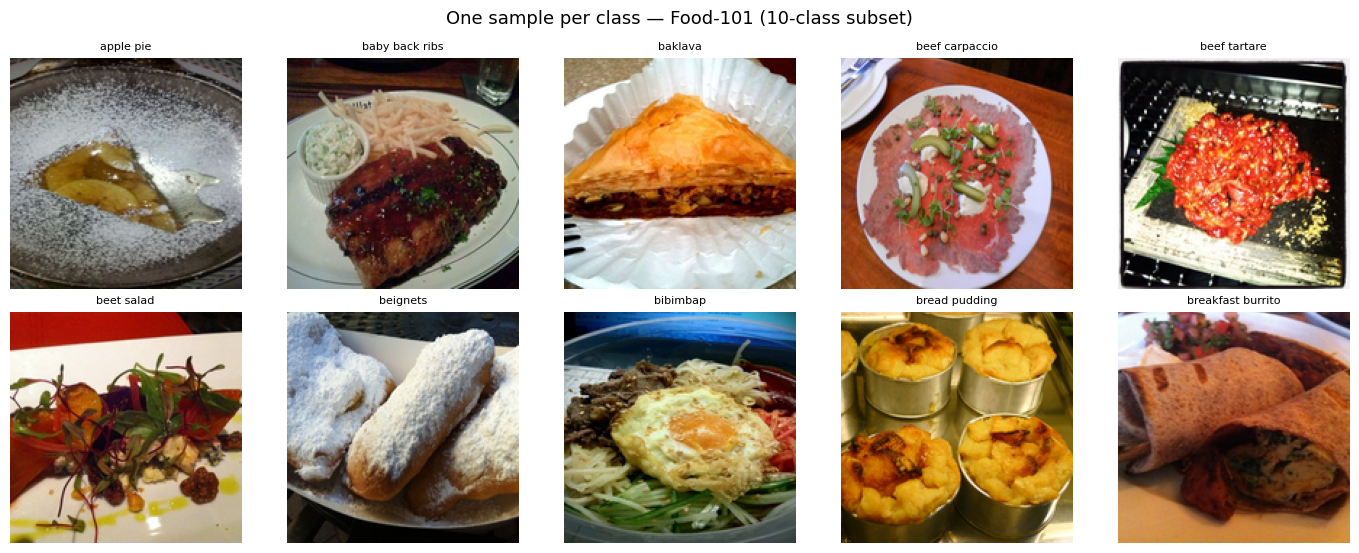

In [3]:

# -- 2.1 visual  One sample per class grid --
import math
from PIL import Image

N_SHOW   = 10    # classes to display (change to 101 for all)
COLS     = 5
IMG_SIZE = 160

# Re-derive class_names here so this cell works even if the Food-101 loading
# cell's kernel state was lost (e.g. after an auto-restart).
class_names  = ds_train.classes          # list of 101 food names
classes_show = class_names[:N_SHOW]
class_to_idx = ds_train.class_to_idx

# Build the exact set of integer class labels we need images for
# Bug fix: the original scan stopped after finding any N_SHOW distinct labels,
# which could be {0, 2, 5, ...} — not necessarily the labels 0..N_SHOW-1 that
# the display loop looks up. Collect only the labels we will actually display.
wanted       = {class_to_idx[cls_name] for cls_name in classes_show}
idx_to_first = {}
for ds_idx in range(len(ds_train)):
    _, label = ds_train[ds_idx]
    if label in wanted and label not in idx_to_first:
        idx_to_first[label] = ds_idx
    if len(idx_to_first) == len(wanted):
        break

rows = math.ceil(N_SHOW / COLS)
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 2.8, rows * 2.8))
axes = axes.flatten()

for ax_i, cls_name in enumerate(classes_show):
    cls_int = class_to_idx[cls_name]
    img, _  = ds_train[idx_to_first[cls_int]]
    img     = img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    axes[ax_i].imshow(img)
    axes[ax_i].set_title(cls_name.replace("_", " "), fontsize=8)
    axes[ax_i].axis("off")

for ax_i in range(N_SHOW, len(axes)):
    axes[ax_i].set_visible(False)

plt.suptitle(f"One sample per class — Food-101 ({N_SHOW}-class subset)", fontsize=13)
plt.tight_layout()
plt.show()



### 2.2 — Load WineSensed Reviews (raw)

Downloads `data/all/all_dataset.jsonl` (357 MB) directly from Hugging Face using `hf_hub_download`.
File is cached to `data/` — subsequent runs load from disk instantly.

**This cell loads raw data only.** Missing values, non-English reviews, duplicates, and short reviews
are all expected and intentionally kept here. They will be removed in Section 3.

**Dataset:** WineSensed (NeurIPS 2023) — 824k real Vivino user tasting notes.
Licence: CC BY-NC-ND 4.0 (non-commercial research use).

**Key columns after loading:**

| Column | Content |
|---|---|
| `review_text` | Raw Vivino tasting note (renamed from `review`) |
| `wine_label` | Wine name + vintage year (e.g. *"Château Margaux 2015"*) |
| `grape` | Comma-separated grape varieties, primary grape first |
| `rating_pct` | Vivino avg rating (0–5) → converted to approval % |
| `country` / `region` | Wine origin |



In [4]:

# ── 2.2  Load WineSensed Reviews (raw) ───────────────────────────────────────
# Dataset : Dakhoo/L2T-NeurIPS-2023 — WineSensed (NeurIPS 2023)
# Licence : CC BY-NC-ND 4.0 — non-commercial research use
#
# The dataset's loading script is broken (references all.tar.gz which does not
# exist — the repo only has all_dataset.jsonl). We download the JSONL directly.
#
# No cleaning here. Missing values, non-English reviews, and duplicates are
# all expected — they will be handled in Section 3.

import shutil
from huggingface_hub import hf_hub_download

_jsonl_path = DATA_DIR / "all_dataset.jsonl"

if not _jsonl_path.exists():
    print("Downloading all_dataset.jsonl from Hugging Face (~357 MB) …")
    _downloaded = hf_hub_download(
        repo_id   = "Dakhoo/L2T-NeurIPS-2023",
        filename  = "data/all/all_dataset.jsonl",
        repo_type = "dataset",
        local_dir = str(DATA_DIR),
    )
    if str(_downloaded) != str(_jsonl_path):
        shutil.copy(_downloaded, str(_jsonl_path))
    print(f"Saved to {_jsonl_path}")
else:
    print(f"Using cached file: {_jsonl_path}")

print("\nReading JSONL …")
df_wine = pd.read_json(_jsonl_path, lines=True)
print(f"Raw shape : {df_wine.shape}")

# ── Normalise column names ────────────────────────────────────────────────────
df_wine.columns = [c.strip().lower().replace(" ", "_") for c in df_wine.columns]
print(f"Columns   : {df_wine.columns.tolist()}")

# ── Standardise review column → review_text ───────────────────────────────────
for _cand in ["review_text", "review", "reviews"]:
    if _cand in df_wine.columns:
        if _cand != "review_text":
            df_wine = df_wine.rename(columns={_cand: "review_text"})
        break

# ── wine_label = wine name + vintage year ─────────────────────────────────────
if "wine" in df_wine.columns and "year" in df_wine.columns:
    df_wine["wine_label"] = (
        df_wine["wine"].fillna("").astype(str).str.strip()
        + " "
        + df_wine["year"].fillna("").astype(str).str.strip()
    ).str.strip()
elif "wine" in df_wine.columns:
    df_wine["wine_label"] = df_wine["wine"].astype(str).str.strip()
else:
    df_wine["wine_label"] = ""

# ── rating_pct : Vivino avg rating (0–5) → user approval % ──────────────────
if "rating" in df_wine.columns:
    df_wine["rating_pct"] = (
        pd.to_numeric(df_wine["rating"], errors="coerce")
        .clip(0, 5)
        .div(5.0)
        .mul(100)
        .round(0)
        .astype("Int64")
    )

# ── Preview ───────────────────────────────────────────────────────────────────
_PREVIEW = ["wine_label", "review_text", "rating_pct", "grape", "country", "region"]
_preview_cols = [c for c in _PREVIEW if c in df_wine.columns]

pd.set_option("display.max_colwidth", 90)
display(df_wine[_preview_cols].head(5))
pd.reset_option("display.max_colwidth")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:99: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


all_dataset.jsonl:   0%|          | 0.00/357M [00:00<?, ?B/s]

Saved to data/all_dataset.jsonl

Reading JSONL …
Raw shape : (1010152, 14)
Columns   : ['vintage_id', 'image', 'review', 'experiment_id', 'year', 'winery_id', 'wine_alcohol', 'country', 'region', 'price', 'rating', 'grape', 'vintage_page_url', 'wine']


,wine_label,review_text,rating_pct,grape,country,region
0,,"Ничего особого в нем не нашел. В меру сухое, вкус не сильно выражен. Для тихого вечера...",<NA>,None,None,None
1,,None,<NA>,None,None,None
2,,None,<NA>,None,None,None
3,,"3,3/5. Белая Риоха. Бленд на основе виуры (75%) и 25% все остальное - белое семь сорто...",<NA>,None,None,None
4,,Parfum! Super frumos!,<NA>,None,None,None


In [5]:

# ── 2.2  Raw data shape check ─────────────────────────────────────────────────
# Confirms the JSONL was parsed correctly. Missing values are expected at this
# stage — they will be cleaned in Section 3. Don't be alarmed by high null %.

print(f"{'Raw rows':<25}: {len(df_wine):,}")
print(f"{'Columns':<25}: {df_wine.shape[1]}")
print()

# ── Null counts for the four columns we will need ────────────────────────────
print(f"{'Column':<20} {'Non-null':>10}  {'Null':>8}  {'Null %':>7}")
print("-" * 48)
for col in ["review_text", "grape", "wine_label", "rating_pct"]:
    if col in df_wine.columns:
        non_null = df_wine[col].notna().sum()
        null     = df_wine[col].isna().sum()
        pct      = null / len(df_wine) * 100
        print(f"  {col:<18} {non_null:>10,}  {null:>8,}  {pct:>6.1f}%")

print(f"\n✓ Section 2.2 complete — {len(df_wine):,} raw rows loaded.")
print("  Missing values and non-English reviews will be removed in Section 3.")


Raw rows                 : 1,010,152
Columns                  : 16

Column                 Non-null      Null   Null %
------------------------------------------------
  review_text           947,476    62,676     6.2%
  grape                  45,339   964,813    95.5%
  wine_label          1,010,152         0     0.0%
  rating_pct             45,339   964,813    95.5%

✓ Section 2.2 complete — 1,010,152 raw rows loaded.
  Missing values and non-English reviews will be removed in Section 3.


---

## Section 3 — Data Cleaning

**Best practice:** always clean data *before* EDA and *before* model training.
If you clean after plotting, your charts describe data the model never sees — that is misleading.
Every statistic in Section 4 (review length, grape distribution, word clouds) should reflect
the data the models will actually train on.

Food-101 image data needs no cleaning — torchvision downloads a curated, balanced dataset with
no missing labels or corrupted files. Only the WineSensed text data is cleaned here.

### Why each cleaning step matters

| Step | What is removed | Why |
|---|---|---|
| Missing essentials | Rows with no review, grape, wine name, or rating | All four are required — missing any one makes the row useless for training or output |
| Zero rating | Wines rated 0.0 | Vivino encodes "not yet rated" as 0.0 — it is not a genuine score; showing 0% on the recommendation card would be wrong |
| Short reviews | Reviews shorter than 5 words | Too little text for the BiLSTM to learn from; also adds noise to Word2Vec vocabulary |
| Non-English | Reviews with < 80% ASCII characters | Google News Word2Vec is English-only — non-Latin-script reviews produce near-zero vectors |
| Duplicates | Identical review text | The same Vivino review can be attached to multiple wine vintages; duplicates bias training class distributions |

---

### 3.1 — Clean WineSensed



In [6]:

# ── 3.1  Clean WineSensed Reviews — setup ────────────────────────────────────
_raw_count = len(df_wine)
_step      = {}

# Helper: detect empty / null / placeholder values
def _is_empty(s):
    return (
        s.isna()
        | (s.astype(str).str.strip() == "")
        | (s.astype(str).str.lower().str.strip() == "none")
    )

print(f"Starting row count: {_raw_count:,}")


Starting row count: 1,010,152


In [7]:

# ── Step 1: Drop rows missing any essential column ────────────────────────────
# review_text : BiLSTM training text + review retrieval output
# grape       : classification label + Word2Vec grape embedding target
# wine_label  : bottle name shown on the recommendation card
# rating_pct  : approval % shown on the recommendation card
_n    = len(df_wine)
_drop = (
    _is_empty(df_wine["review_text"])
    | _is_empty(df_wine["grape"])
    | _is_empty(df_wine["wine_label"])
    | df_wine["rating_pct"].isna()
)
df_wine = df_wine[~_drop].copy()
_step["1  missing essentials"] = _n - len(df_wine)

print(f"Step 1 — dropped {_step['1  missing essentials']:,} rows (missing essentials)  |  remaining: {len(df_wine):,}")


Step 1 — dropped 965,145 rows (missing essentials)  |  remaining: 45,007


In [8]:

# ── Step 2: Drop zero-rated wines ─────────────────────────────────────────────
# Vivino encodes "not yet rated" as 0.0 — not a genuine score.
# Showing 0% approval on the recommendation card would be wrong.
_n      = len(df_wine)
df_wine = df_wine[df_wine["rating_pct"] > 0].copy()
_step["2  zero rating (0%)"] = _n - len(df_wine)

print(f"Step 2 — dropped {_step['2  zero rating (0%)']:,} rows (zero rating)  |  remaining: {len(df_wine):,}")


Step 2 — dropped 0 rows (zero rating)  |  remaining: 45,007


In [9]:

# ── Step 3: Drop very short reviews (< 5 words) ───────────────────────────────
# Reviews shorter than 5 words carry almost no semantic signal for the BiLSTM
# and add noise to the Word2Vec fine-tuning vocabulary.
_n      = len(df_wine)
df_wine = df_wine[df_wine["review_text"].str.split().str.len() >= 5].copy()
_step["3  review < 5 words"] = _n - len(df_wine)

print(f"Step 3 — dropped {_step['3  review < 5 words']:,} rows (review < 5 words)  |  remaining: {len(df_wine):,}")


Step 3 — dropped 6,165 rows (review < 5 words)  |  remaining: 38,842


In [10]:

# ── Step 4: Drop non-English reviews ──────────────────────────────────────────
# Google News Word2Vec is English-only. A French or Italian review will have
# near-zero vectors for most tokens — noise, not signal.
#
# Heuristic: keep rows where >= 80% of characters are plain ASCII (codes 0-127).
# This reliably filters CJK, Cyrillic, Arabic, Greek, etc. while keeping English
# and close Latin-script languages that share vocabulary with English anyway.
_n           = len(df_wine)
_ascii_ratio = df_wine["review_text"].apply(
    lambda t: sum(ord(c) < 128 for c in str(t)) / max(len(str(t)), 1)
)
df_wine = df_wine[_ascii_ratio >= 0.80].copy()
_step["4  non-English (ASCII < 80%)"] = _n - len(df_wine)

print(f"Step 4 — dropped {_step['4  non-English (ASCII < 80%)']:,} rows (non-English)  |  remaining: {len(df_wine):,}")


Step 4 — dropped 52 rows (non-English)  |  remaining: 38,790


In [11]:

# ── 3.1  Summary ──────────────────────────────────────────────────────────────
print(f"{'Cleaning step':<42} {'Dropped':>8}  {'%':>5}")
print("─" * 58)
for step, dropped in _step.items():
    pct = dropped / _raw_count * 100
    print(f"  Step {step:<37} {dropped:>8,}  {pct:>4.1f}%")
print("─" * 58)
total_dropped = _raw_count - len(df_wine)
print(f"  {'Total dropped':<40} {total_dropped:>8,}  {total_dropped / _raw_count * 100:>4.1f}%")
print(f"  {'Clean rows remaining':<40} {len(df_wine):>8,}")
print(f"\n✓ Section 3.1 complete — df_wine is clean and ready for EDA and model training.")


Cleaning step                               Dropped      %
──────────────────────────────────────────────────────────
  Step 1  missing essentials                  965,145  95.5%
  Step 2  zero rating (0%)                          0   0.0%
  Step 3  review < 5 words                      6,165   0.6%
  Step 4  non-English (ASCII < 80%)                52   0.0%
──────────────────────────────────────────────────────────
  Total dropped                             971,362  96.2%
  Clean rows remaining                       38,790

✓ Section 3.1 complete — df_wine is clean and ready for EDA and model training.


### 3.2 — Select top 15 grape varieties as classification labels

Rather than grouping wines into broad types (Red / White / Rosé), we use the **primary grape variety** directly as the BiLSTM classification target. This forces the model to learn the fine-grained flavor language specific to each grape — *"cassis and cedar"* for Cabernet Sauvignon vs *"strawberry and silk"* for Pinot Noir.

We select the **top 15 grapes by review count** from the `grape` column (first entry in the comma-separated list). These 15 varieties typically cover ~85% of all reviews. Rows whose primary grape is not in the top 15 are dropped.

**Why this runs after cleaning:** grape frequency counts are computed on clean data only. Running this on raw data would inflate some counts with rows that will be dropped later (duplicates, non-English, etc.) and could distort which 15 grapes are selected.

**Expected result:** New `grape_class` column with one of 15 grape names. Distribution printed.

**Validation checks:**
- Exactly 15 unique values in `grape_class`
- Distribution printed (check for severe imbalance)
- No nulls in `grape_class`



In [12]:

# ── 3.2  Select top N grapes — Step 1: Extract primary grape ─────────────────
# Primary grape = first entry in the comma-separated `grape` column.

TOP_N_GRAPES = 15

df_wine["primary_grape"] = (
    df_wine["grape"]
    .fillna("")
    .str.split(",")
    .str[0]
    .str.strip()
)

print(f"Unique primary grapes found : {df_wine['primary_grape'].nunique():,}")
print(f"Sample values : {df_wine['primary_grape'].value_counts().head(5).to_dict()}")


Unique primary grapes found : 29
Sample values : {'Sangiovese': 15175, 'Shiraz/Syrah': 6545, 'Merlot': 3779, 'Pinot Noir': 2834, 'Tempranillo': 2463}


In [13]:

# ── 3.2  Step 2: Find top N grapes by review count ────────────────────────────
grape_counts = df_wine["primary_grape"].value_counts()
top_grapes   = grape_counts.head(TOP_N_GRAPES).index.tolist()

print(f"Top {TOP_N_GRAPES} grapes selected (out of {df_wine['primary_grape'].nunique()} unique):\n")
print(", ".join(top_grapes))


Top 15 grapes selected (out of 29 unique):

Sangiovese, Shiraz/Syrah, Merlot, Pinot Noir, Tempranillo, Primitivo, Cabernet Sauvignon, Aglianico, Tinta Roriz, Corvina, Cabernet Franc, Nebbiolo, Montepulciano, Monastrell, Barbera


In [14]:

# ── 3.2  Step 3: Filter df_wine to top N grapes & assign grape_class ──────────
df_wine["grape_class"] = df_wine["primary_grape"].where(
    df_wine["primary_grape"].isin(top_grapes)
)
df_wine_mapped = df_wine.dropna(subset=["grape_class"]).copy()

coverage = len(df_wine_mapped) / len(df_wine) * 100
print(f"Rows kept    : {len(df_wine_mapped):>10,}  ({coverage:.1f}% of reviews)")
print(f"Rows dropped : {len(df_wine) - len(df_wine_mapped):>10,}  "
      f"(primary grape not in top {TOP_N_GRAPES})")


Rows kept    :     37,719  (97.2% of reviews)
Rows dropped :      1,071  (primary grape not in top 15)


In [15]:

# ── 3.2  Step 5: Distribution table & expose GRAPE_CLASSES ───────────────────
dist = df_wine_mapped["grape_class"].value_counts()

print(f"{'Grape variety':<28} {'Count':>8}  {'%':>6}")
print("-" * 46)
for grape, count in dist.items():
    pct = count / len(df_wine_mapped) * 100
    bar = "█" * int(pct / 2)
    print(f"{grape:<28} {count:>8,}  {pct:>5.1f}%  {bar}")

# Expose the ordered class list for later sections
GRAPE_CLASSES = dist.index.tolist()   # ordered by frequency

print(f"\n✓ Section 3.2 complete — grape_class column added ({TOP_N_GRAPES} classes).")


Grape variety                   Count       %
----------------------------------------------
Sangiovese                     15,175   40.2%  ████████████████████
Shiraz/Syrah                    6,545   17.4%  ████████
Merlot                          3,779   10.0%  █████
Pinot Noir                      2,834    7.5%  ███
Tempranillo                     2,463    6.5%  ███
Primitivo                       1,765    4.7%  ██
Cabernet Sauvignon              1,537    4.1%  ██
Aglianico                       1,133    3.0%  █
Tinta Roriz                       819    2.2%  █
Corvina                           480    1.3%  
Cabernet Franc                    302    0.8%  
Nebbiolo                          297    0.8%  
Montepulciano                     237    0.6%  
Monastrell                        180    0.5%  
Barbera                           173    0.5%  

✓ Section 3.2 complete — grape_class column added (15 classes).


### 3.2.1 — Food-101 Image Class Balance Check

Before building the flavor table it is worth confirming that the image dataset has no class-imbalance problem. An imbalanced image dataset would bias the CNN toward over-represented classes, and that error would propagate all the way into wine recommendations.

**Food-101 spec (by design):** 1,000 images per class — 750 train + 250 test × 101 classes.

**Validation checks:**
- Min and max image counts per class are equal in both splits
- All 101 classes are present in both splits


### 3.3 — Food flavor table

The food flavor table is the bridge between the CNN's food label and the wine pairing system.
It is embedded directly as a Python dictionary — no file dependency.

Each of the 101 Food-101 classes has three sets of flavor keywords:

| Key | Purpose | Example for `pizza` |
|---|---|---|
| `complement` | Flavors that echo and amplify the food's dominant taste — points toward grapes with matching character | `savory tomato earthy herbaceous rich fatty` |
| `contrast` | Flavors that cut through the food and refresh the palate — points toward grapes with high acidity or minerality | `mineral crisp citrus steely dry acidic` |
| `balance` | Approachable, crowd-safe — points toward lighter, fruit-forward grapes | `light fruity clean gentle soft easy` |

Because Word2Vec is **pre-trained on Google News** before being fine-tuned on WineSensed reviews, the flavor table can use natural food language — *tomato*, *fatty*, *smoky*, *creamy* — alongside wine tasting words. All of these have meaningful vectors in the shared space. There is no need to restrict keywords to wine vocabulary only.

At inference time, keywords from the relevant set are embedded using the fine-tuned Word2Vec model (Section 6) and compared by cosine similarity against the 15 grape embedding vectors. The top-matching grape is selected, and the highest-rated real wine of that grape is retrieved with the most representative Vivino review.

**Validation checks:**
- All 101 Food-101 class names are present as keys
- Each entry has exactly 3 keys: `complement`, `contrast`, `balance`
- No empty keyword lists



In [ ]:
# ── 3.3  Food flavor table ────────────────────────────────────────────────────
# One entry per Food-101 class. Each entry has three keyword lists:
#   complement : flavors that echo and amplify the dish
#   contrast   : flavors that cut through and refresh
#   balance    : crowd-safe, approachable pairings
#
# Keywords use plain taste/texture language (tomato, fatty, smoky, creamy) that
# Word2Vec already knows from Google News, plus wine tasting terms that land in
# the same vector space after fine-tuning on WineSensed reviews.
# No wine vocabulary is required — the embedding handles the translation.

FOOD_FLAVOR_TABLE = {
    "apple_pie": {
        "complement": "sweet cinnamon spiced warm baked caramel fruity",
        "contrast":   "crisp acidic citrus tart refreshing light dry",
        "balance":    "soft gentle fruity light clean easy",
    },
    "baby_back_ribs": {
        "complement": "smoky rich savory meaty charred woody barbecue",
        "contrast":   "crisp acidic citrus bright refreshing mineral dry",
        "balance":    "fruity smooth soft light easy approachable",
    },
    "baklava": {
        "complement": "sweet honey nutty rich syrupy spiced warm",
        "contrast":   "crisp acidic citrus tart dry refreshing mineral",
        "balance":    "soft gentle fruity light floral clean",
    },
    "beef_carpaccio": {
        "complement": "savory umami earthy rich fatty mineral raw",
        "contrast":   "crisp acidic citrus bright light tart refreshing",
        "balance":    "soft fruity gentle light clean smooth",
    },
    "beef_tartare": {
        "complement": "savory umami raw earthy rich fatty tangy",
        "contrast":   "crisp acidic mineral bright dry sparkling",
        "balance":    "soft fruity gentle light clean smooth",
    },
    "beet_salad": {
        "complement": "earthy sweet mineral vegetal fresh herbal",
        "contrast":   "crisp acidic citrus bright tart dry",
        "balance":    "soft fruity light clean gentle floral",
    },
    "beignets": {
        "complement": "sweet doughy rich fried powdered warm caramel",
        "contrast":   "crisp acidic citrus tart refreshing light dry",
        "balance":    "soft fruity gentle floral light easy",
    },
    "bibimbap": {
        "complement": "savory umami sesame earthy spicy fermented rice",
        "contrast":   "crisp acidic citrus bright refreshing mineral dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "bread_pudding": {
        "complement": "sweet rich creamy warm vanilla custard caramel",
        "contrast":   "crisp acidic citrus tart refreshing light dry",
        "balance":    "soft gentle fruity light clean easy",
    },
    "breakfast_burrito": {
        "complement": "savory spicy smoky egg cheese rich hearty",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "bruschetta": {
        "complement": "tomato herbal garlic savory fresh olive oily",
        "contrast":   "crisp acidic mineral citrus dry bright",
        "balance":    "soft fruity light clean gentle easy",
    },
    "caesar_salad": {
        "complement": "savory salty umami creamy anchovy lemony crisp",
        "contrast":   "crisp acidic mineral bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "cannoli": {
        "complement": "sweet creamy ricotta rich chocolate vanilla pastry",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "caprese_salad": {
        "complement": "tomato herbal basil milky fresh olive oily",
        "contrast":   "crisp acidic mineral citrus dry bright",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "carrot_cake": {
        "complement": "sweet spiced warm cinnamon cream cheese rich",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "ceviche": {
        "complement": "citrus bright acidic fresh seafood tangy mineral",
        "contrast":   "rich creamy oaky buttery smooth full",
        "balance":    "soft fruity light clean gentle floral",
    },
    "cheese_plate": {
        "complement": "rich creamy nutty savory salty milky aged",
        "contrast":   "crisp acidic mineral bright dry tart",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "cheesecake": {
        "complement": "sweet creamy rich vanilla graham buttery smooth",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "chicken_curry": {
        "complement": "spiced warm aromatic turmeric rich creamy savory",
        "contrast":   "crisp acidic citrus bright refreshing dry mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "chicken_quesadilla": {
        "complement": "savory cheesy smoky spicy rich hearty",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "chicken_wings": {
        "complement": "savory spicy smoky charred rich meaty",
        "contrast":   "crisp acidic citrus bright refreshing mineral dry",
        "balance":    "soft fruity light clean gentle easy",
    },
    "chocolate_cake": {
        "complement": "rich dark sweet chocolate bitter cocoa mocha",
        "contrast":   "crisp acidic tart raspberry bright refreshing",
        "balance":    "soft gentle fruity light smooth easy",
    },
    "chocolate_mousse": {
        "complement": "rich dark sweet chocolate silky cocoa cream",
        "contrast":   "crisp acidic tart raspberry bright refreshing",
        "balance":    "soft gentle fruity light smooth easy",
    },
    "churros": {
        "complement": "sweet cinnamon fried warm doughy caramel sugar",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "clam_chowder": {
        "complement": "creamy briny seafood rich savory buttery starchy",
        "contrast":   "crisp acidic mineral citrus dry bright",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "club_sandwich": {
        "complement": "savory salty meaty creamy rich hearty",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "crab_cakes": {
        "complement": "briny seafood savory buttery rich delicate",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle floral",
    },
    "creme_brulee": {
        "complement": "sweet creamy rich vanilla custard caramel warm",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "croque_madame": {
        "complement": "savory cheesy buttery rich egg creamy hearty",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "cup_cakes": {
        "complement": "sweet rich creamy frosting vanilla buttery soft",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "deviled_eggs": {
        "complement": "savory creamy tangy rich eggy smooth",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "donuts": {
        "complement": "sweet fried doughy glazed warm caramel vanilla",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "dumplings": {
        "complement": "savory umami pork ginger soy rich steamed",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "edamame": {
        "complement": "fresh green vegetal salty light clean mineral",
        "contrast":   "crisp acidic citrus bright tart dry",
        "balance":    "soft fruity light clean gentle floral",
    },
    "eggs_benedict": {
        "complement": "rich creamy buttery savory hollandaise egg smoky",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "escargots": {
        "complement": "buttery garlic herbal savory rich earthy",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "falafel": {
        "complement": "earthy herbal spiced chickpea savory crispy",
        "contrast":   "crisp acidic citrus bright tart refreshing",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "filet_mignon": {
        "complement": "rich savory meaty umami tender fatty earthy",
        "contrast":   "crisp acidic mineral citrus bright tart",
        "balance":    "soft fruity smooth light gentle easy",
    },
    "fish_and_chips": {
        "complement": "briny savory crispy fried fatty starchy malt",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "foie_gras": {
        "complement": "rich fatty buttery luxurious savory sweet earthy",
        "contrast":   "crisp acidic tart citrus bright dry mineral",
        "balance":    "soft fruity gentle light floral smooth",
    },
    "french_fries": {
        "complement": "salty starchy crispy savory fatty rich",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "french_onion_soup": {
        "complement": "savory rich umami caramelized sweet beefy cheesy",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "french_toast": {
        "complement": "sweet rich eggy creamy warm cinnamon caramel",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "fried_calamari": {
        "complement": "briny seafood savory crispy light lemony",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "fried_rice": {
        "complement": "savory umami soy sesame egg rich starchy",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "frozen_yogurt": {
        "complement": "sweet tart creamy tangy light fruity cold",
        "contrast":   "crisp acidic citrus bright tart refreshing",
        "balance":    "soft gentle fruity light floral easy",
    },
    "garlic_bread": {
        "complement": "savory buttery garlic herbal rich crispy",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "gnocchi": {
        "complement": "savory starchy rich buttery creamy herbal soft",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "greek_salad": {
        "complement": "fresh herbal salty briny olive oily tomato crisp",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "grilled_cheese_sandwich": {
        "complement": "rich creamy melted cheesy buttery savory warm",
        "contrast":   "crisp acidic mineral citrus bright dry tart",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "grilled_salmon": {
        "complement": "rich fatty oily savory smoky charred ocean",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle floral",
    },
    "guacamole": {
        "complement": "rich creamy fatty avocado citrus fresh herbal",
        "contrast":   "crisp acidic mineral citrus bright dry tart",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "gyoza": {
        "complement": "savory umami pork ginger soy rich pan-fried",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "hamburger": {
        "complement": "rich savory meaty fatty charred smoky hearty",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "hot_and_sour_soup": {
        "complement": "sour spicy umami earthy rich pungent savory",
        "contrast":   "rich creamy smooth oaky buttery full",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "hot_dog": {
        "complement": "savory salty meaty smoky mustard rich",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "huevos_rancheros": {
        "complement": "savory spicy tomato rich egg hearty smoky",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "hummus": {
        "complement": "earthy creamy savory nutty herbal tahini olive",
        "contrast":   "crisp acidic citrus bright tart refreshing",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "ice_cream": {
        "complement": "sweet creamy rich vanilla cold smooth dairy",
        "contrast":   "crisp acidic tart raspberry bright refreshing",
        "balance":    "soft gentle fruity light floral easy",
    },
    "lasagna": {
        "complement": "rich savory meaty tomato cheesy herbal hearty",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "lobster_bisque": {
        "complement": "rich creamy briny sweet seafood buttery luxurious",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle floral",
    },
    "lobster_roll_sandwich": {
        "complement": "briny sweet rich creamy seafood buttery fresh",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle floral",
    },
    "macaroni_and_cheese": {
        "complement": "rich creamy cheesy starchy savory buttery warm",
        "contrast":   "crisp acidic mineral citrus bright dry tart",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "macarons": {
        "complement": "sweet delicate floral fruity almond cream elegant",
        "contrast":   "crisp acidic tart citrus bright dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "miso_soup": {
        "complement": "savory umami salty earthy fermented light warm",
        "contrast":   "crisp acidic citrus bright refreshing tart",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "mussels": {
        "complement": "briny oceanic savory garlicky white wine herbal",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "nachos": {
        "complement": "savory spicy cheesy rich fatty crunchy smoky",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "omelette": {
        "complement": "savory creamy eggy buttery rich herbal soft",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "onion_rings": {
        "complement": "savory sweet crispy fried fatty starchy caramelized",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "oysters": {
        "complement": "briny mineral oceanic saline fresh delicate",
        "contrast":   "rich creamy oaky buttery full warm",
        "balance":    "soft fruity light clean gentle floral",
    },
    "pad_thai": {
        "complement": "savory sweet sour tangy nutty spicy noodle",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "paella": {
        "complement": "savory smoky saffron seafood rich rice earthy",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "pancakes": {
        "complement": "sweet warm buttery maple syrupy soft rich",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "panna_cotta": {
        "complement": "sweet creamy silky delicate vanilla gentle smooth",
        "contrast":   "crisp acidic tart citrus bright refreshing",
        "balance":    "soft gentle fruity light floral easy",
    },
    "peking_duck": {
        "complement": "rich savory fatty smoky crispy skin sweet hoisin",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "pho": {
        "complement": "savory umami brothy spiced herbal star anise warm",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "pizza": {
        "complement": "savory tomato earthy herbaceous rich fatty cheesy",
        "contrast":   "mineral crisp citrus steely dry acidic",
        "balance":    "light fruity clean gentle soft easy",
    },
    "pork_chop": {
        "complement": "savory rich meaty fatty smoky charred juicy",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "poutine": {
        "complement": "rich savory gravy fatty cheesy starchy hearty",
        "contrast":   "crisp acidic mineral citrus bright dry tart",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "prime_rib": {
        "complement": "rich savory meaty fatty umami earthy hearty",
        "contrast":   "crisp acidic mineral tart bright dry",
        "balance":    "soft fruity smooth light gentle easy",
    },
    "pulled_pork_sandwich": {
        "complement": "smoky sweet savory rich fatty barbecue tangy",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "ramen": {
        "complement": "savory umami rich brothy pork soy fatty warm",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "ravioli": {
        "complement": "savory rich buttery cheesy herbal starchy soft",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "red_velvet_cake": {
        "complement": "sweet rich creamy chocolate cream cheese tangy",
        "contrast":   "crisp acidic tart citrus bright refreshing",
        "balance":    "soft gentle fruity light floral easy",
    },
    "risotto": {
        "complement": "rich creamy savory starchy umami buttery earthy",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "samosa": {
        "complement": "spiced savory earthy crispy potato pea warm",
        "contrast":   "crisp acidic citrus bright refreshing tart",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "sashimi": {
        "complement": "delicate fresh oceanic clean mineral raw light",
        "contrast":   "rich creamy oaky buttery full warm",
        "balance":    "soft fruity light clean gentle floral",
    },
    "scallops": {
        "complement": "sweet delicate briny buttery caramelized rich",
        "contrast":   "crisp acidic mineral citrus bright dry sparkling",
        "balance":    "soft fruity light clean gentle floral",
    },
    "seaweed_salad": {
        "complement": "oceanic mineral fresh umami sesame briny light",
        "contrast":   "crisp acidic citrus bright tart dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "shrimp_and_grits": {
        "complement": "savory rich creamy buttery briny cheesy hearty",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "spaghetti_bolognese": {
        "complement": "savory meaty tomato rich earthy herbal hearty",
        "contrast":   "crisp acidic mineral citrus bright dry",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "spaghetti_carbonara": {
        "complement": "rich creamy savory fatty egg cheese pancetta",
        "contrast":   "crisp acidic mineral citrus bright dry tart",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "spring_rolls": {
        "complement": "fresh crispy light savory herbal vegetal delicate",
        "contrast":   "crisp acidic citrus bright tart refreshing",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "steak": {
        "complement": "rich savory meaty fatty umami charred earthy",
        "contrast":   "crisp acidic mineral tart bright dry",
        "balance":    "soft fruity smooth light gentle easy",
    },
    "strawberry_shortcake": {
        "complement": "sweet fresh fruity cream berry light floral",
        "contrast":   "crisp acidic tart citrus bright dry",
        "balance":    "soft gentle fruity light floral easy",
    },
    "sushi": {
        "complement": "delicate fresh oceanic clean umami rice vinegar",
        "contrast":   "rich creamy oaky buttery full warm",
        "balance":    "soft fruity light clean gentle floral",
    },
    "tacos": {
        "complement": "savory spicy smoky meaty citrus herbal fresh",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "takoyaki": {
        "complement": "savory umami octopus dashi rich crispy soy",
        "contrast":   "crisp acidic citrus bright refreshing mineral",
        "balance":    "soft fruity light clean gentle smooth",
    },
    "tiramisu": {
        "complement": "rich coffee sweet cream mascarpone cocoa dark",
        "contrast":   "crisp acidic tart citrus bright refreshing",
        "balance":    "soft gentle fruity light smooth easy",
    },
    "tuna_tartare": {
        "complement": "fresh oceanic mineral clean citrus savory sesame",
        "contrast":   "rich creamy oaky buttery full warm",
        "balance":    "soft fruity light clean gentle floral",
    },
    "waffles": {
        "complement": "sweet warm buttery maple syrupy rich soft",
        "contrast":   "crisp acidic citrus tart refreshing dry",
        "balance":    "soft gentle fruity light floral easy",
    },
}

# ── Validation ────────────────────────────────────────────────────────────────
_food101_classes = ds_train.classes   # loaded in Section 2.1

_missing = [c for c in _food101_classes if c not in FOOD_FLAVOR_TABLE]
_extra   = [c for c in FOOD_FLAVOR_TABLE if c not in _food101_classes]

assert len(_missing) == 0, f"Missing from flavor table: {_missing}"
assert len(_extra)   == 0, f"Extra keys not in Food-101: {_extra}"

for food, profile in FOOD_FLAVOR_TABLE.items():
    assert set(profile.keys()) == {"complement", "contrast", "balance"}, \
        f"{food} missing a pairing key"
    for intent, kws in profile.items():
        assert len(kws.strip().split()) >= 4, \
            f"{food}.{intent} has fewer than 4 keywords"

print(f"Food flavor table: {len(FOOD_FLAVOR_TABLE)} entries, 3 keyword sets each.")
print(f"Example — pizza:")
for intent, kws in FOOD_FLAVOR_TABLE["pizza"].items():
    print(f"  {intent:<12} {kws}")
print(f"\n✓ Section 3.3 complete — FOOD_FLAVOR_TABLE validated against Food-101 classes.")

---

### 3.4 — Train / Val / Test Split (WineSensed)

**This split must happen before Section 4 (EDA).** Computing statistics such as `MAX_SEQ_LEN`, word clouds, or class distributions on the full dataset lets test-set information silently influence model architecture decisions — a subtle but real form of data leakage.

| Split | Size | Purpose |
|---|---|---|
| **train** (70%) | `df_train` | Model training, vocabulary building, Word2Vec fine-tuning |
| **val** (15%) | `df_val` | Early stopping, hyperparameter tuning |
| **test** (15%) | `df_test` | Final evaluation only — touched once per model |

Stratified by `grape_class` so every split preserves the same class proportions as the full cleaned dataset.


In [ ]:

# ── 3.4  Train / Val / Test split — WineSensed ───────────────────────────────
# Split BEFORE EDA (Section 4) so all statistics — review length percentiles,
# word clouds, class distributions — are computed on training data only.
# Computing them on the full dataset would let test-set information silently
# influence MAX_SEQ_LEN and other decisions baked into the model.
#
# 70 / 15 / 15 stratified by grape_class so every split preserves the same
# class proportions as the full cleaned dataset.
from sklearn.model_selection import train_test_split

GRAPE_TO_IDX = {g: i for i, g in enumerate(GRAPE_CLASSES)}

_df     = df_wine_mapped.copy()
_labels = _df["grape_class"].map(GRAPE_TO_IDX)

df_train, _df_tmp = train_test_split(
    _df, test_size=0.30, stratify=_labels, random_state=SEED
)
df_val, df_test = train_test_split(
    _df_tmp, test_size=0.50,
    stratify=_df_tmp["grape_class"].map(GRAPE_TO_IDX),
    random_state=SEED
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"{'Split':<8} {'Rows':>8}  {'%':>5}")
print("-" * 25)
for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name:<8} {len(df):>8,}  {len(df)/len(df_wine_mapped)*100:>4.1f}%")
print(f"{'total':<8} {len(df_train)+len(df_val)+len(df_test):>8,}")

print(f"\n⛔ Test set frozen — df_test must not be inspected until Section 11/13 final evaluation.")
print(f"   EDA in Section 4 uses df_train only.")
print(f"\n✓ Section 3.4 complete.")


---

## ⛔ Test Set Freeze

**The test sets are now frozen. Do not inspect, plot, or evaluate on them until the final model evaluation cells in Sections 7, 8, 11, and 13.**

| Dataset | Train | Val | Test | Frozen from |
|---|---|---|---|---|
| Food-101 (images) | 60,600 | 15,150 | 25,250 | Section 5 onward |
| WineSensed (text) | 70% → `df_train` | 15% → `df_val` | 15% → `df_test` | **Section 3.4 onward** |

All architecture decisions, hyperparameter tuning, and early stopping use **validation loss/accuracy only**.
The test sets are touched exactly once per model — at the final evaluation cell.

---


---

## Section 4 — Exploratory Data Analysis

EDA runs on clean data only (after Section 3). Every chart here describes exactly what the models will train on.

Two sub-sections:
- **4.1** — Image dataset: sample grid, class distribution, image dimensions
- **4.2** — Text dataset: review length distribution → `MAX_SEQ_LEN`, grape class distribution, word clouds, sample reviews

`MAX_SEQ_LEN` is defined at the end of 4.2 and reused in Section 6.

---

In [ ]:

# ── 4.1  Image EDA ────────────────────────────────────────────────────────────

# ── Sample image grid (18 classes × 2 images) ────────────────────────────────
sample_classes = random.sample(ds_train.classes, 18)
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle("Food-101 — sample images (2 per class)", fontsize=14)

for ax, cls in zip(axes.flat, sample_classes):
    # find indices for this class
    cls_idx  = ds_train.classes.index(cls)
    # Bug fix: ds_train._labels is List[int], not List[Tuple] — unpack as single int
    matches  = [i for i, lbl in enumerate(ds_train._labels) if lbl == cls_idx]
    img_path = ds_train._image_files[random.choice(matches)]
    img      = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls.replace("_", " "), fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES / "eda_image_grid.png", dpi=100)
plt.show()

# ── Class distribution ────────────────────────────────────────────────────────
train_counts = Counter(ds_train._labels)
counts_sorted = sorted(train_counts.values())

fig, ax = plt.subplots(figsize=(18, 4))
ax.bar(range(101), counts_sorted, color="steelblue", width=1.0)
ax.axhline(750, color="red", linestyle="--", label="Expected 750/class")
ax.set_xlabel("Class index (sorted by count)")
ax.set_ylabel("Images")
ax.set_title("Food-101 train — class distribution (should be ~750 per class)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "eda_image_class_dist.png", dpi=100)
plt.show()

print(f"Min images/class : {min(counts_sorted)}")
print(f"Max images/class : {max(counts_sorted)}")
print(f"Mean             : {sum(counts_sorted)/len(counts_sorted):.1f}")
print(f"\n✓ Section 4.1 complete.")


In [ ]:

# ── 4.2  Text EDA ─────────────────────────────────────────────────────────────
# Uses df_train only — split was done in Section 3.4 (before EDA) to prevent
# test-set statistics from influencing MAX_SEQ_LEN or any other model decision.

# ── Review length distribution ────────────────────────────────────────────────
lengths = df_train["review_text"].str.split().str.len()

p50  = int(lengths.quantile(0.50))
p90  = int(lengths.quantile(0.90))
p95  = int(lengths.quantile(0.95))
p99  = int(lengths.quantile(0.99))

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(lengths.clip(upper=300), bins=80, color="steelblue", edgecolor="none")
for pct, val, col in [(50, p50, "green"), (90, p90, "orange"), (95, p95, "red"), (99, p99, "purple")]:
    ax.axvline(val, color=col, linestyle="--", label=f"p{pct} = {val}")
ax.set_xlabel("Review length (words)")
ax.set_ylabel("Count")
ax.set_title("WineSensed review length distribution — training set (clipped at 300)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "eda_review_lengths.png", dpi=100)
plt.show()

print(f"p50 = {p50} words | p90 = {p90} | p95 = {p95} | p99 = {p99}")
print(f"Choosing MAX_SEQ_LEN = p95 = {p95}")
pct_truncated = (lengths > p95).mean() * 100
print(f"Reviews truncated at p95: {pct_truncated:.1f}%")

# ── Define MAX_SEQ_LEN — used by Section 6 ───────────────────────────────────
MAX_SEQ_LEN = p95
print(f"\nMAX_SEQ_LEN = {MAX_SEQ_LEN}  (reused in Section 6 DataLoaders)")

# ── Grape class distribution ──────────────────────────────────────────────────
grape_dist = df_train["grape_class"].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
grape_dist.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("WineSensed — grape class distribution (training set, top 15)")
ax.set_xlabel("Grape variety")
ax.set_ylabel("Reviews")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES / "eda_grape_dist.png", dpi=100)
plt.show()

imbalance_ratio = grape_dist.max() / grape_dist.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f}x")
if imbalance_ratio > 3:
    print("  ⚠  Significant imbalance detected — weighted CrossEntropyLoss used in Sections 10/11.")
else:
    print("  ✓ Imbalance acceptable.")

# ── Word clouds per grape (15 clouds) ─────────────────────────────────────────
from wordcloud import WordCloud
from nltk.corpus import stopwords

_stopwords = set(stopwords.words("english")) | {"wine", "drink", "bottle", "glass"}

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle("WineSensed — word clouds per grape variety (training set)", fontsize=14)

for ax, grape in zip(axes.flat, GRAPE_CLASSES):
    text = " ".join(df_train[df_train["grape_class"] == grape]["review_text"])
    wc = WordCloud(
        width=300, height=200, background_color="white",
        stopwords=_stopwords, max_words=60, collocations=False
    ).generate(text)
    # Bug fix: pass the rendered PIL image directly — avoids numpy 2.x / wordcloud
    # incompatibility where WordCloud.__array__ passes copy= kwarg not accepted by np.asarray
    ax.imshow(wc.to_image(), interpolation="bilinear")
    ax.set_title(grape, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES / "eda_wordclouds.png", dpi=100)
plt.show()

# ── 3 sample reviews per grape (first 3 grapes only for brevity) ──────────────
print("\nSample reviews (3 per grape, first 3 grapes):\n")
for grape in GRAPE_CLASSES[:3]:
    samples = df_train[df_train["grape_class"] == grape]["review_text"].sample(3, random_state=SEED)
    print(f"── {grape} ──")
    for rev in samples:
        print(f"  • {rev[:120]}")
    print()

print("✓ Section 4.2 complete.")


---

## Section 5 — Image Preprocessing and Data Loaders

**Requires GPU — run in Google Colab.**

Food-101 ships with only a train split (75,750) and a test split (25,250). There is no built-in validation split. We carve one out of the official train split here: **80 / 20** → ~60,600 train / ~15,150 val. The test split (25,250) remains untouched.

### Augmentation choices

| Transform | Why |
|---|---|
| `RandomHorizontalFlip` | Food photos are horizontally symmetric — a pizza looks the same flipped |
| `RandomRotation(15°)` | Dishes are photographed at varying angles |
| `ColorJitter` | Lighting varies significantly across restaurant photos |
| `CenterCrop(224)` applied to val/test | Consistent crop at inference — no stochastic augmentation |
| `Normalize(ImageNet mean/std)` | ResNet-50 was pre-trained on ImageNet — same normalisation required |

---

In [ ]:
# ── 5.1  Transforms ───────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize(256),
    T.RandomCrop(224),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── 5.2  Carve validation split from Food-101 train ──────────────────────────
# Food-101 has no built-in val split. We split the official train set 80/20.
# Stratified by class so every grape class is represented in val.
from torch.utils.data import Subset
from sklearn.model_selection import StratifiedShuffleSplit

_labels = [ds_train[i][1] for i in range(len(ds_train))]
_sss    = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
_train_idx, _val_idx = next(_sss.split(range(len(ds_train)), _labels))

# Wrap with appropriate transforms
class _TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label

_base_train = tv_datasets.Food101(root=FOOD101_ROOT, split="train", download=False,
                                   transform=None)
_base_test  = tv_datasets.Food101(root=FOOD101_ROOT, split="test",  download=False,
                                   transform=None)

img_train_ds = _TransformSubset(Subset(_base_train, _train_idx), train_transform)
img_val_ds   = _TransformSubset(Subset(_base_train, _val_idx),   val_test_transform)
img_test_ds  = _TransformSubset(_base_test,                       val_test_transform)

# ── 5.3  DataLoaders ──────────────────────────────────────────────────────────
IMG_BATCH = 64

img_train_loader = DataLoader(img_train_ds, batch_size=IMG_BATCH, shuffle=True,
                               num_workers=2, pin_memory=True)
img_val_loader   = DataLoader(img_val_ds,   batch_size=IMG_BATCH, shuffle=False,
                               num_workers=2, pin_memory=True)
img_test_loader  = DataLoader(img_test_ds,  batch_size=IMG_BATCH, shuffle=False,
                               num_workers=2, pin_memory=True)

# ── Validation ────────────────────────────────────────────────────────────────
print(f"{'Split':<10} {'Samples':>8}  {'Batches':>8}")
print("-" * 30)
print(f"{'train':<10} {len(img_train_ds):>8,}  {len(img_train_loader):>8,}")
print(f"{'val':<10} {len(img_val_ds):>8,}  {len(img_val_loader):>8,}")
print(f"{'test':<10} {len(img_test_ds):>8,}  {len(img_test_loader):>8,}")

imgs, labels = next(iter(img_train_loader))
assert imgs.shape == (IMG_BATCH, 3, 224, 224), f"Unexpected shape: {imgs.shape}"
print(f"\nBatch shape : {imgs.shape}  (B, C, H, W)")
print(f"Label range : {labels.min().item()} – {labels.max().item()}")
print(f"\n✓ Section 5 complete — image DataLoaders ready.")

---

## Section 6 — Text Preprocessing and Data Loaders

### Two separate embedding systems — why both are needed

| Embedding | Purpose | Model |
|---|---|---|
| **GloVe 100-d** | BiLSTM token embedding layer (trained with the classifier) | `glove-wiki-gigaword-100` via gensim |
| **Word2Vec 300-d** | Flavor pairing system (food keywords → grape cosine similarity) | Google News pre-trained, fine-tuned on WineSensed |

GloVe is used for the BiLSTM because 100-d is fast to train on CPU and has good coverage of wine tasting vocabulary. Word2Vec is used for the pairing system because the Google News base already knows food words (*tomato*, *fatty*, *smoky*) in the same vector space as wine words after fine-tuning.

### Correct step order (data leakage prevention)

```
1. Train / val / test split  ← must come FIRST
2. Tokenise all splits
3. Build vocabulary on TRAINING tokens only
4. Load GloVe → build embedding matrix from training vocab
5. Compute class weights from TRAINING labels only
6. Fine-tune Word2Vec on TRAINING reviews only
7. Compute grape embeddings from TRAINING reviews only
8. Pad / truncate to MAX_SEQ_LEN
9. Build DataLoaders
```

Steps 3–7 use only training data. Val and test data pass through the same vocab/tokeniser but do not influence it.

---

In [ ]:

# ── 6.1  Extract text/label lists from the pre-split DataFrames ──────────────
# The 70/15/15 stratified split was done in Section 3.4 (before EDA).
# Here we just unpack the DataFrames into list format for the rest of Section 6.
import string

txt_train = df_train["review_text"].tolist()
lbl_train = df_train["grape_class"].map(GRAPE_TO_IDX).tolist()
txt_val   = df_val["review_text"].tolist()
lbl_val   = df_val["grape_class"].map(GRAPE_TO_IDX).tolist()
txt_test  = df_test["review_text"].tolist()
lbl_test  = df_test["grape_class"].map(GRAPE_TO_IDX).tolist()

print(f"{'Split':<8} {'Samples':>10}")
print("-" * 20)
print(f"{'train':<8} {len(txt_train):>10,}")
print(f"{'val':<8} {len(txt_val):>10,}")
print(f"{'test':<8} {len(txt_test):>10,}")
print(f"{'total':<8} {len(txt_train)+len(txt_val)+len(txt_test):>10,}")

# ── 6.2  Tokenise ─────────────────────────────────────────────────────────────
_punct = str.maketrans("", "", string.punctuation)

def tokenise(text):
    return text.lower().translate(_punct).split()

tok_train = [tokenise(t) for t in txt_train]
tok_val   = [tokenise(t) for t in txt_val]
tok_test  = [tokenise(t) for t in txt_test]

# ── 6.3  Build vocabulary on TRAINING tokens only ────────────────────────────
# Val and test see the same vocab but do not influence it.
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
MIN_FREQ  = 3   # ignore tokens appearing fewer than 3 times in training

_train_counts = Counter(tok for sent in tok_train for tok in sent)
_vocab_words  = [w for w, c in _train_counts.items() if c >= MIN_FREQ]

VOCAB      = {PAD_TOKEN: 0, UNK_TOKEN: 1}
VOCAB.update({w: i + 2 for i, w in enumerate(_vocab_words)})
VOCAB_SIZE = len(VOCAB)

pct_unk_train = sum(1 for s in tok_train for w in s if w not in VOCAB) / \
                max(sum(len(s) for s in tok_train), 1) * 100
pct_unk_val   = sum(1 for s in tok_val   for w in s if w not in VOCAB) / \
                max(sum(len(s) for s in tok_val),   1) * 100

print(f"\nVocabulary size : {VOCAB_SIZE:,}")
print(f"OOV rate (train): {pct_unk_train:.2f}%")
print(f"OOV rate (val)  : {pct_unk_val:.2f}%")

# ── 6.4  Load GloVe and build embedding matrix ───────────────────────────────
# GloVe used for the BiLSTM token embedding layer.
# Download once (~66 MB) via gensim; cached locally afterward.
print("\nLoading GloVe 100-d ...")
glove_kv  = gensim_api.load("glove-wiki-gigaword-100")
EMBED_DIM = 100

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)
n_found = 0
for word, idx in VOCAB.items():
    if word in glove_kv:
        embedding_matrix[idx] = glove_kv[word]
        n_found += 1

print(f"GloVe coverage : {n_found / max(VOCAB_SIZE, 1) * 100:.1f}% of vocab tokens found")

# ── 6.5  Class weights (from TRAINING labels only) ────────────────────────────
# Corrects for class imbalance in CrossEntropyLoss.
from sklearn.utils.class_weight import compute_class_weight
_cw = compute_class_weight("balanced", classes=np.arange(len(GRAPE_CLASSES)), y=lbl_train)
# Keep on CPU — move to DEVICE only when passed to criterion inside a training cell
CLASS_WEIGHTS = torch.tensor(_cw, dtype=torch.float32)
print(f"\nClass weights (min={CLASS_WEIGHTS.min():.2f}, max={CLASS_WEIGHTS.max():.2f})")

# ── 6.6  Fine-tune Word2Vec on TRAINING reviews only ─────────────────────────
# Google News base gives food vocabulary; fine-tuning on WineSensed reviews
# adds wine tasting words and shifts vectors toward wine semantic space.
# ONLY training sentences are used — no val/test leakage.
#
# Bug fix: the original code loaded Google News into w2v_model and then
# immediately overwrote it with a blank Word2Vec() — the pre-trained weights
# were never used. The correct approach:
#   1. Build a new Word2Vec on training vocab.
#   2. Pre-seed its weight matrix from Google News for any shared words.
#   3. Fine-tune with the training corpus.
print("\nLoading Google News Word2Vec base (~1.6 GB, first run ~2 min) ...")
_w2v_base = gensim_api.load("word2vec-google-news-300")

print("Building Word2Vec model on training vocabulary ...")
w2v_model = Word2Vec(vector_size=300, min_count=1, seed=SEED, workers=4)
w2v_model.build_vocab(tok_train)

# Pre-seed with Google News vectors for known words
_n_seeded = 0
for word in list(w2v_model.wv.key_to_index.keys()):
    if word in _w2v_base.key_to_index:
        w2v_model.wv[word] = _w2v_base[word]
        _n_seeded += 1
print(f"Pre-seeded {_n_seeded:,} / {len(w2v_model.wv):,} vocabulary tokens from Google News")

print("Fine-tuning Word2Vec on training reviews ...")
w2v_model.train(tok_train, total_examples=len(tok_train), epochs=5)
w2v_model.save(str(WEIGHTS / "w2v_finetuned.model"))
print(f"Saved → {WEIGHTS / 'w2v_finetuned.model'}")

# ── 6.7  Grape embeddings from TRAINING reviews only ─────────────────────────
def embed_keywords(keywords_str, model):
    vecs = [model.wv[w] for w in keywords_str.split() if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(300)

grape_embeddings = {}
for grape in GRAPE_CLASSES:
    train_reviews = [t for t, l in zip(tok_train, lbl_train)
                     if GRAPE_CLASSES[l] == grape]
    all_words = [w for rev in train_reviews for w in rev if w in w2v_model.wv]
    grape_embeddings[grape] = (np.mean([w2v_model.wv[w] for w in all_words], axis=0)
                                if all_words else np.zeros(300))

np.save(str(WEIGHTS / "grape_embeddings.npy"), grape_embeddings)
print(f"Grape embeddings saved → {WEIGHTS / 'grape_embeddings.npy'}")

# ── 6.8  Encode and pad ───────────────────────────────────────────────────────
def encode_and_pad(tokens, max_len):
    ids = [VOCAB.get(w, VOCAB[UNK_TOKEN]) for w in tokens[:max_len]]
    ids += [VOCAB[PAD_TOKEN]] * (max_len - len(ids))
    return ids

X_train = np.array([encode_and_pad(t, MAX_SEQ_LEN) for t in tok_train], dtype=np.int64)
X_val   = np.array([encode_and_pad(t, MAX_SEQ_LEN) for t in tok_val],   dtype=np.int64)
X_test  = np.array([encode_and_pad(t, MAX_SEQ_LEN) for t in tok_test],  dtype=np.int64)

pct_trunc = sum(len(t) > MAX_SEQ_LEN for t in tok_train) / len(tok_train) * 100
print(f"\nPadded/truncated to MAX_SEQ_LEN={MAX_SEQ_LEN}  ({pct_trunc:.1f}% truncated)")

# ── 6.9  DataLoaders ──────────────────────────────────────────────────────────
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):  return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

TXT_BATCH = 64
txt_train_loader = DataLoader(ReviewDataset(X_train, lbl_train), batch_size=TXT_BATCH, shuffle=True)
txt_val_loader   = DataLoader(ReviewDataset(X_val,   lbl_val),   batch_size=TXT_BATCH, shuffle=False)
txt_test_loader  = DataLoader(ReviewDataset(X_test,  lbl_test),  batch_size=TXT_BATCH, shuffle=False)

xb, yb = next(iter(txt_train_loader))
print(f"Text batch shape : {xb.shape}  (B, MAX_SEQ_LEN)")
print(f"\n✓ Section 6 complete — text DataLoaders ready.")


---

## Section 7 — CNN: Custom Architecture (Trained from Scratch)

**Requires GPU — run in Google Colab.**

### Architecture

Three convolutional blocks followed by a classifier head:

```
Block 1: Conv2d(3→64, 3×3)   → BN → ReLU → MaxPool2d(2×2)
Block 2: Conv2d(64→128, 3×3) → BN → ReLU → MaxPool2d(2×2)
Block 3: Conv2d(128→256, 3×3)→ BN → ReLU → MaxPool2d(2×2)
         AdaptiveAvgPool2d(1×1) → Flatten(256)
Head:    FC(256→512) → ReLU → Dropout(0.5) → FC(512→101)
```

### Training protocol
- 20 epochs, early stopping on val loss (patience = 3)
- Adam lr=1e-3, ReduceLROnPlateau (factor=0.5, patience=2)
- **Checkpoint saved every epoch** — training can resume after Colab disconnect

---

In [ ]:
# ── 7.1  Architecture ─────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
    def forward(self, x): return self.block(x)

class CNNScratch(nn.Module):
    def __init__(self, n_classes=101):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   64),
            ConvBlock(64,  128),
            ConvBlock(128, 256),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

    def encode(self, x):
        """Return 256-d feature vector (used by joint model)."""
        return self.features(x).squeeze(-1).squeeze(-1)

cnn_scratch = CNNScratch().to(DEVICE)
total_params = sum(p.numel() for p in cnn_scratch.parameters())
train_params = sum(p.numel() for p in cnn_scratch.parameters() if p.requires_grad)
print(f"CNN scratch — total params: {total_params:,}  trainable: {train_params:,}")

# Sanity-check forward pass
_dummy = torch.randn(2, 3, 224, 224).to(DEVICE)
assert cnn_scratch(_dummy).shape == (2, 101)
print("Forward pass: OK → shape (2, 101)")

# ── 7.2  Training loop ────────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += len(labels)
    return total_loss / n, correct / n

criterion_cnn = nn.CrossEntropyLoss()
optimizer_scratch = Adam(cnn_scratch.parameters(), lr=1e-3)
scheduler_scratch = ReduceLROnPlateau(optimizer_scratch, factor=0.5, patience=2, verbose=True)

# ── 7.3  Training with per-epoch checkpoints ─────────────────────────────────
MAX_EPOCHS    = 20
PATIENCE      = 3
best_val_loss = float("inf")
patience_ctr  = 0
history_scratch = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(cnn_scratch, img_train_loader, criterion_cnn, optimizer_scratch)
    vl_loss, vl_acc = evaluate(cnn_scratch, img_val_loader, criterion_cnn)
    scheduler_scratch.step(vl_loss)

    history_scratch["train_loss"].append(tr_loss)
    history_scratch["val_loss"].append(vl_loss)
    history_scratch["train_acc"].append(tr_acc)
    history_scratch["val_acc"].append(vl_acc)

    # Save checkpoint every epoch (resume-safe after Colab disconnect)
    torch.save({
        "epoch": epoch,
        "model_state": cnn_scratch.state_dict(),
        "optimizer_state": optimizer_scratch.state_dict(),
        "val_loss": vl_loss,
    }, WEIGHTS / f"cnn_scratch_ckpt_ep{epoch:02d}.pt")

    print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | "
          f"val loss {vl_loss:.4f} acc {vl_acc:.3f}")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_ctr  = 0
        torch.save(cnn_scratch.state_dict(), WEIGHTS / "cnn_scratch.pt")
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

# ── 7.4  Learning curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history_scratch["train_loss"], label="train")
ax1.plot(history_scratch["val_loss"],   label="val")
ax1.set_title("CNN Scratch — Loss"); ax1.legend()
ax2.plot(history_scratch["train_acc"], label="train")
ax2.plot(history_scratch["val_acc"],   label="val")
ax2.set_title("CNN Scratch — Accuracy"); ax2.legend()
plt.tight_layout()
plt.savefig(FIGURES / "cnn_scratch_curves.png", dpi=100)
plt.show()

# ── 7.5  Final test evaluation (test set used once here) ─────────────────────
cnn_scratch.load_state_dict(torch.load(WEIGHTS / "cnn_scratch.pt"))
_, test_acc = evaluate(cnn_scratch, img_test_loader, criterion_cnn)

all_preds, all_labels = [], []
cnn_scratch.eval()
with torch.no_grad():
    for imgs, labels in img_test_loader:
        preds = cnn_scratch(imgs.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

from sklearn.metrics import classification_report, f1_score, confusion_matrix
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"\nCNN Scratch — Test accuracy: {test_acc:.4f}  Macro F1: {macro_f1:.4f}")
print(classification_report(all_labels, all_preds,
                              target_names=ds_train.classes, zero_division=0))
print(f"✓ Section 7 complete — weights saved to {WEIGHTS / 'cnn_scratch.pt'}")

---

## Section 8 — CNN: ResNet-50 (Transfer Learning)

**Requires GPU — run in Google Colab.**

### Two-phase fine-tuning

| Phase | Layers trained | Epochs | LR |
|---|---|---|---|
| A | Classification head only (frozen backbone) | 5 | 1e-3 |
| B | Head + `layer4` unfrozen | 10 | 1e-4 |

Phase A trains quickly and finds a good starting point for the head. Phase B fine-tunes the top ResNet block with a lower learning rate to avoid destroying ImageNet features.

---

In [ ]:
# ── 8.1  Build ResNet-50 ──────────────────────────────────────────────────────
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Freeze all layers
for p in resnet50.parameters():
    p.requires_grad = False

# Replace classification head → 101 classes
resnet50.fc = nn.Linear(2048, 101)
resnet50    = resnet50.to(DEVICE)

frozen  = sum(p.numel() for p in resnet50.parameters() if not p.requires_grad)
trained = sum(p.numel() for p in resnet50.parameters() if p.requires_grad)
print(f"ResNet-50 — frozen: {frozen:,}  trainable: {trained:,}")

assert resnet50(torch.randn(2, 3, 224, 224).to(DEVICE)).shape == (2, 101)
print("Forward pass: OK → shape (2, 101)")

# ── 8.2  Phase A — head only ──────────────────────────────────────────────────
opt_rn = Adam(resnet50.fc.parameters(), lr=1e-3)
sch_rn = ReduceLROnPlateau(opt_rn, factor=0.5, patience=2, verbose=True)
hist_rn = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print("\n── Phase A (frozen backbone, head only) ──")
for epoch in range(1, 6):
    tr_loss, tr_acc = train_one_epoch(resnet50, img_train_loader, criterion_cnn, opt_rn)
    vl_loss, vl_acc = evaluate(resnet50, img_val_loader, criterion_cnn)
    sch_rn.step(vl_loss)
    hist_rn["train_loss"].append(tr_loss); hist_rn["val_loss"].append(vl_loss)
    hist_rn["train_acc"].append(tr_acc);  hist_rn["val_acc"].append(vl_acc)
    torch.save({"epoch": epoch, "model_state": resnet50.state_dict(), "val_loss": vl_loss},
               WEIGHTS / f"cnn_resnet50_ckpt_ep{epoch:02d}.pt")
    print(f"  Ep {epoch} | train {tr_loss:.4f}/{tr_acc:.3f} | val {vl_loss:.4f}/{vl_acc:.3f}")

# ── 8.3  Phase B — unfreeze layer4 ───────────────────────────────────────────
print("\n── Phase B (layer4 + head unfrozen) ──")
for p in resnet50.layer4.parameters():
    p.requires_grad = True

opt_rn_b = Adam(filter(lambda p: p.requires_grad, resnet50.parameters()), lr=1e-4)
sch_rn_b = ReduceLROnPlateau(opt_rn_b, factor=0.5, patience=2, verbose=True)
best_rn_loss = float("inf")

for epoch in range(6, 16):
    tr_loss, tr_acc = train_one_epoch(resnet50, img_train_loader, criterion_cnn, opt_rn_b)
    vl_loss, vl_acc = evaluate(resnet50, img_val_loader, criterion_cnn)
    sch_rn_b.step(vl_loss)
    hist_rn["train_loss"].append(tr_loss); hist_rn["val_loss"].append(vl_loss)
    hist_rn["train_acc"].append(tr_acc);  hist_rn["val_acc"].append(vl_acc)
    torch.save({"epoch": epoch, "model_state": resnet50.state_dict(), "val_loss": vl_loss},
               WEIGHTS / f"cnn_resnet50_ckpt_ep{epoch:02d}.pt")
    print(f"  Ep {epoch} | train {tr_loss:.4f}/{tr_acc:.3f} | val {vl_loss:.4f}/{vl_acc:.3f}")
    if vl_loss < best_rn_loss:
        best_rn_loss = vl_loss
        torch.save(resnet50.state_dict(), WEIGHTS / "cnn_resnet50.pt")

# ── 8.4  Learning curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(hist_rn["train_loss"], label="train"); ax1.plot(hist_rn["val_loss"], label="val")
ax1.axvline(4.5, color="gray", linestyle=":", label="Phase A→B")
ax1.set_title("ResNet-50 — Loss"); ax1.legend()
ax2.plot(hist_rn["train_acc"],  label="train"); ax2.plot(hist_rn["val_acc"],  label="val")
ax2.axvline(4.5, color="gray", linestyle=":")
ax2.set_title("ResNet-50 — Accuracy"); ax2.legend()
plt.tight_layout()
plt.savefig(FIGURES / "cnn_resnet50_curves.png", dpi=100)
plt.show()

# ── 8.5  Final test evaluation ────────────────────────────────────────────────
resnet50.load_state_dict(torch.load(WEIGHTS / "cnn_resnet50.pt"))
_, rn_test_acc = evaluate(resnet50, img_test_loader, criterion_cnn)

rn_preds, rn_labels = [], []
resnet50.eval()
with torch.no_grad():
    for imgs, labels in img_test_loader:
        preds = resnet50(imgs.to(DEVICE)).argmax(1).cpu()
        rn_preds.extend(preds.tolist()); rn_labels.extend(labels.tolist())

rn_f1 = f1_score(rn_labels, rn_preds, average="macro")
print(f"\nResNet-50  — Test accuracy: {rn_test_acc:.4f}  Macro F1: {rn_f1:.4f}")
print(f"CNN Scratch — Test accuracy: {test_acc:.4f}  Macro F1: {macro_f1:.4f}")
print(f"\n✓ Section 8 complete — weights saved to {WEIGHTS / 'cnn_resnet50.pt'}")

---

## Section 9 — CNN Explainability: Grad-CAM

Grad-CAM visualises which spatial regions of a food photo drove the CNN's classification decision. We show 6 examples: 2 correct predictions, 2 wrong predictions, and 2 where top-1 is wrong but the correct class is in top-5.

---

In [ ]:
# ── 9  Grad-CAM explainability ────────────────────────────────────────────────
from torchcam.methods import GradCAM
from torchcam.utils  import overlay_mask
from torchvision.transforms.functional import to_pil_image

resnet50.load_state_dict(torch.load(WEIGHTS / "cnn_resnet50.pt", map_location=DEVICE))
resnet50.eval()

cam_extractor = GradCAM(resnet50, target_layer="layer4")

# Collect 6 examples: 2 correct, 2 wrong top-1, 2 top-5 correct
examples = {"correct": [], "wrong": [], "top5_correct": []}
for imgs, labels in img_test_loader:
    imgs, labels = imgs.to(DEVICE), labels
    logits = resnet50(imgs)
    top5   = logits.topk(5, dim=1).indices.cpu()
    top1   = logits.argmax(1).cpu()
    for i in range(len(labels)):
        lbl = labels[i].item()
        if top1[i] == lbl and len(examples["correct"]) < 2:
            examples["correct"].append((imgs[i], lbl, top1[i].item()))
        elif top1[i] != lbl and lbl not in top5[i].tolist() and len(examples["wrong"]) < 2:
            examples["wrong"].append((imgs[i], lbl, top1[i].item()))
        elif top1[i] != lbl and lbl in top5[i].tolist() and len(examples["top5_correct"]) < 2:
            examples["top5_correct"].append((imgs[i], lbl, top1[i].item()))
    if all(len(v) >= 2 for v in examples.values()):
        break

all_examples = (
    [("correct",      *e) for e in examples["correct"]] +
    [("wrong",        *e) for e in examples["wrong"]] +
    [("top-5 hit",    *e) for e in examples["top5_correct"]]
)

fig, axes = plt.subplots(2, 6, figsize=(22, 8))
class_names = ds_train.classes

for col, (case, img_t, true_lbl, pred_lbl) in enumerate(all_examples):
    logits = resnet50(img_t.unsqueeze(0))
    cam    = cam_extractor(pred_lbl, logits)[0]

    # Original image (un-normalise)
    orig = img_t.cpu() * torch.tensor(IMAGENET_STD).view(3,1,1) \
               + torch.tensor(IMAGENET_MEAN).view(3,1,1)
    orig = orig.clamp(0, 1)

    overlay = overlay_mask(to_pil_image(orig), to_pil_image(cam.squeeze(0)), alpha=0.5)

    axes[0, col].imshow(to_pil_image(orig))
    axes[0, col].set_title(f"True: {class_names[true_lbl]}\nPred: {class_names[pred_lbl]}\n[{case}]",
                            fontsize=7)
    axes[0, col].axis("off")

    axes[1, col].imshow(overlay)
    axes[1, col].set_title("Grad-CAM", fontsize=7)
    axes[1, col].axis("off")

plt.suptitle("Grad-CAM — ResNet-50 on Food-101 test images", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES / "gradcam.png", dpi=100)
plt.show()
cam_extractor.remove_hooks()
print("✓ Section 9 complete.")

---

## Section 10 — LSTM Baseline

Unidirectional LSTM trained on CPU. Serves as the baseline for comparison with BiLSTM in Section 11.

**Architecture:** GloVe embedding (frozen) → LSTM(hidden=128) → Linear(128→15)

Random baseline for 15 classes = 6.7% accuracy.

---

In [ ]:

# ── 10  LSTM Baseline ─────────────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, embed_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embed_matrix, dtype=torch.float32), requires_grad=False
        )
        self.lstm       = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout    = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        return self.classifier(self.dropout(h.squeeze(0)))

lstm_model = LSTMClassifier(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=128,
    n_classes=len(GRAPE_CLASSES), embed_matrix=embedding_matrix
).to(DEVICE)

print(f"LSTM params: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

# Move CLASS_WEIGHTS to DEVICE here — it was kept on CPU in Section 6 to avoid
# a CUDA health-check failure at weight computation time
criterion_txt = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE))
opt_lstm      = Adam(filter(lambda p: p.requires_grad, lstm_model.parameters()), lr=1e-3)
hist_lstm     = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def train_txt_epoch(model, loader, criterion, optimizer):
    model.train(); total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n

@torch.no_grad()
def eval_txt(model, loader, criterion):
    model.eval(); total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        n          += len(yb)
    return total_loss / n, correct / n

for epoch in range(1, 4):
    tr_l, tr_a = train_txt_epoch(lstm_model, txt_train_loader, criterion_txt, opt_lstm)
    vl_l, vl_a = eval_txt(lstm_model, txt_val_loader, criterion_txt)
    hist_lstm["train_loss"].append(tr_l); hist_lstm["val_loss"].append(vl_l)
    hist_lstm["train_acc"].append(tr_a);  hist_lstm["val_acc"].append(vl_a)
    print(f"Epoch {epoch} | train {tr_l:.4f}/{tr_a:.3f} | val {vl_l:.4f}/{vl_a:.3f}")

# Test evaluation
_, lstm_test_acc = eval_txt(lstm_model, txt_test_loader, criterion_txt)
lstm_preds, lstm_lbls = [], []
lstm_model.eval()
with torch.no_grad():
    for xb, yb in txt_test_loader:
        lstm_preds.extend(lstm_model(xb.to(DEVICE)).argmax(1).cpu().tolist())
        lstm_lbls.extend(yb.tolist())

lstm_f1 = f1_score(lstm_lbls, lstm_preds, average="macro")
print(f"\nLSTM — Test accuracy: {lstm_test_acc:.4f}  Macro F1: {lstm_f1:.4f}")
print(f"(Random baseline: {1/len(GRAPE_CLASSES):.4f})")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3))
a1.plot(hist_lstm["train_loss"], label="train"); a1.plot(hist_lstm["val_loss"], label="val")
a1.set_title("LSTM — Loss"); a1.legend()
a2.plot(hist_lstm["train_acc"],  label="train"); a2.plot(hist_lstm["val_acc"],  label="val")
a2.set_title("LSTM — Accuracy"); a2.legend()
plt.tight_layout(); plt.savefig(FIGURES / "lstm_curves.png", dpi=100); plt.show()
print("✓ Section 10 complete.")


---

## Section 11 — BiLSTM with Attention

### Dual role

The BiLSTM serves two purposes in this project:

1. **Classifier** — predicts grape variety from a tasting note (15 classes, trained here)
2. **Encoder** — at inference (Section 14), finds the most representative Vivino review per grape by comparing each review's hidden-state vector against the grape centroid

Sub-section 11.3 builds the grape centroids and implements the review retrieval function.

**Architecture:** GloVe embedding → BiLSTM(hidden=128, bidirectional=True, output=256) → attention → Linear(256→15)

---

In [ ]:
# ── 11.1  Architecture ────────────────────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_classes, embed_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embed_matrix, dtype=torch.float32), requires_grad=False
        )
        self.bilstm  = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attn_w  = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(hidden_dim * 2, n_classes)

    def encode(self, x):
        """Return attention-weighted sentence vector [B, 2*hidden]."""
        emb, _ = self.bilstm(self.dropout(self.embedding(x)))
        scores  = self.attn_w(emb).squeeze(-1)           # [B, T]
        weights = torch.softmax(scores, dim=1).unsqueeze(2)  # [B, T, 1]
        return (emb * weights).sum(dim=1), weights        # [B, 256], [B, T, 1]

    def forward(self, x):
        ctx, _ = self.encode(x)
        return self.classifier(self.dropout(ctx))

bilstm_model = BiLSTMAttention(
    vocab_size=VOCAB_SIZE, embed_dim=EMBED_DIM, hidden_dim=128,
    n_classes=len(GRAPE_CLASSES), embed_matrix=embedding_matrix
).to(DEVICE)

print(f"BiLSTM params: {sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad):,}")

# ── 11.2  Train BiLSTM ────────────────────────────────────────────────────────
opt_bi   = Adam(filter(lambda p: p.requires_grad, bilstm_model.parameters()), lr=1e-3)
hist_bi  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_bi_loss = float("inf")

for epoch in range(1, 6):
    tr_l, tr_a = train_txt_epoch(bilstm_model, txt_train_loader, criterion_txt, opt_bi)
    vl_l, vl_a = eval_txt(bilstm_model, txt_val_loader, criterion_txt)
    hist_bi["train_loss"].append(tr_l); hist_bi["val_loss"].append(vl_l)
    hist_bi["train_acc"].append(tr_a);  hist_bi["val_acc"].append(vl_a)
    torch.save({"epoch": epoch, "model_state": bilstm_model.state_dict(), "val_loss": vl_l},
               WEIGHTS / f"bilstm_ckpt_ep{epoch:02d}.pt")
    print(f"Epoch {epoch} | train {tr_l:.4f}/{tr_a:.3f} | val {vl_l:.4f}/{vl_a:.3f}")
    if vl_l < best_bi_loss:
        best_bi_loss = vl_l
        torch.save(bilstm_model.state_dict(), WEIGHTS / "bilstm.pt")

# Test evaluation
_, bi_test_acc = eval_txt(bilstm_model, txt_test_loader, criterion_txt)
bi_preds, bi_lbls = [], []
bilstm_model.eval()
with torch.no_grad():
    for xb, yb in txt_test_loader:
        bi_preds.extend(bilstm_model(xb.to(DEVICE)).argmax(1).cpu().tolist())
        bi_lbls.extend(yb.tolist())

bi_f1 = f1_score(bi_lbls, bi_preds, average="macro")
print(f"\nBiLSTM — Test accuracy: {bi_test_acc:.4f}  Macro F1: {bi_f1:.4f}")
print(f"LSTM   — Test accuracy: {lstm_test_acc:.4f}  Macro F1: {lstm_f1:.4f}")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3))
a1.plot(hist_bi["train_loss"], label="BiLSTM train"); a1.plot(hist_bi["val_loss"], label="BiLSTM val")
a1.plot(hist_lstm["train_loss"], "--", label="LSTM train"); a1.plot(hist_lstm["val_loss"], "--", label="LSTM val")
a1.set_title("Loss comparison"); a1.legend(fontsize=7)
a2.plot(hist_bi["train_acc"], label="BiLSTM train"); a2.plot(hist_bi["val_acc"], label="BiLSTM val")
a2.plot(hist_lstm["train_acc"], "--", label="LSTM train"); a2.plot(hist_lstm["val_acc"], "--", label="LSTM val")
a2.set_title("Accuracy comparison"); a2.legend(fontsize=7)
plt.tight_layout(); plt.savefig(FIGURES / "bilstm_vs_lstm.png", dpi=100); plt.show()

# ── 11.3  BiLSTM as encoder: grape centroids + review retrieval ───────────────
# Build centroid = mean hidden-state vector across all TRAINING reviews per grape.
bilstm_model.load_state_dict(torch.load(WEIGHTS / "bilstm.pt", map_location=DEVICE))
bilstm_model.eval()

grape_centroids = {}
with torch.no_grad():
    for grape_idx, grape in enumerate(GRAPE_CLASSES):
        indices = [i for i, l in enumerate(lbl_train) if l == grape_idx]
        if not indices: continue
        vecs = []
        for i in indices:
            xb = torch.tensor(X_train[i], dtype=torch.long).unsqueeze(0).to(DEVICE)
            ctx, _ = bilstm_model.encode(xb)
            vecs.append(ctx.squeeze(0).cpu().numpy())
        grape_centroids[grape] = np.mean(vecs, axis=0)

np.save(str(WEIGHTS / "grape_centroids.npy"), grape_centroids)

def get_representative_review(grape, df, top_n_candidates=500):
    """Return (review_text, wine_label, rating_pct) for the review
    whose BiLSTM vector is closest to the grape centroid."""
    centroid = grape_centroids[grape]
    candidates = df[df["grape_class"] == grape].nlargest(top_n_candidates, "rating_pct")
    best_score, best_row = -1, None
    bilstm_model.eval()
    with torch.no_grad():
        for _, row in candidates.iterrows():
            tokens = encode_and_pad(tokenise(row["review_text"]), MAX_SEQ_LEN)
            xb = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(DEVICE)
            ctx, _ = bilstm_model.encode(xb)
            vec   = ctx.squeeze(0).cpu().numpy()
            score = np.dot(vec, centroid) / (np.linalg.norm(vec) * np.linalg.norm(centroid) + 1e-9)
            if score > best_score:
                best_score, best_row = score, row
    return best_row["review_text"], best_row["wine_label"], int(best_row["rating_pct"])

print("Testing review retrieval for Cabernet Sauvignon ...")
rev, wine, pct = get_representative_review("Cabernet Sauvignon", df_wine_mapped)
print(f"  Wine   : {wine}")
print(f"  Rating : {pct}%")
print(f"  Review : {rev[:120]} ...")
print(f"\n✓ Section 11 complete — bilstm.pt and grape_centroids.npy saved.")

---

## Section 12 — BiLSTM Explainability: Attention Weights

Renders 6 tasting notes (one per grape variety, sampled from test set) with words colour-highlighted proportionally to their attention weight. High-weight words are the tokens that drove the grape variety prediction.

---

In [ ]:
# ── 12  Attention weight visualisation ───────────────────────────────────────
import matplotlib.colors as mcolors

bilstm_model.load_state_dict(torch.load(WEIGHTS / "bilstm.pt", map_location=DEVICE))
bilstm_model.eval()
IDX_TO_GRAPE = {i: g for g, i in GRAPE_TO_IDX.items()}

# One review per grape, first 6 grapes for readability
fig, axes = plt.subplots(6, 1, figsize=(18, 14))
fig.suptitle("BiLSTM attention weights — which words drove the grape prediction", fontsize=12)

for ax, grape_idx in enumerate(range(6)):
    grape = GRAPE_CLASSES[grape_idx]
    # Pick a correctly-classified test sample for this grape
    sample_idx = next(
        (i for i, (l, p) in enumerate(zip(bi_lbls, bi_preds)) if l == grape_idx and p == l), None
    )
    if sample_idx is None:
        ax.axis("off"); continue

    tokens_ids = X_test[sample_idx]
    xb = torch.tensor(tokens_ids, dtype=torch.long).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        _, weights = bilstm_model.encode(xb)
    weights_np = weights.squeeze().cpu().numpy()

    # Recover word strings (up to actual length, skip PAD)
    IDX_TO_WORD = {v: k for k, v in VOCAB.items()}
    words = [IDX_TO_WORD.get(t, "<UNK>") for t in tokens_ids if t != 0]
    attn  = weights_np[:len(words)]
    attn  = (attn - attn.min()) / (attn.max() - attn.min() + 1e-9)

    # Render coloured text
    cmap = plt.get_cmap("YlOrRd")
    x_pos = 0.0
    for word, weight in zip(words[:30], attn[:30]):  # show first 30 tokens
        color = cmap(weight)
        ax.text(x_pos, 0.5, word + " ", transform=ax.transAxes,
                fontsize=9, color="black", backgroundcolor=color,
                verticalalignment="center")
        x_pos += len(word) * 0.012 + 0.01
        if x_pos > 0.95: break

    ax.set_title(f"{grape} — pred: {IDX_TO_GRAPE[bi_preds[sample_idx]]}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES / "bilstm_attention.png", dpi=100)
plt.show()
print("✓ Section 12 complete.")

---

## Section 13 — Joint Model: Food-Wine Compatibility Classifier (+10 pts)

**Requires GPU — run in Google Colab.**

Pairs are built from **training data only** to prevent leakage into test evaluation.

**Architecture:** frozen CNN encoder (ResNet-50, 2048-d) + frozen BiLSTM encoder (256-d) → concat (2304-d) → FC head → sigmoid

Only the FC head is trained.

---

In [ ]:

#
 
─
─
 
1
3
.
1
 
 
B
u
i
l
d
 
(
i
m
a
g
e
,
 
r
e
v
i
e
w
,
 
l
a
b
e
l
)
 
p
a
i
r
s
 
f
r
o
m
 
T
R
A
I
N
I
N
G
 
d
a
t
a
 
o
n
l
y
 
─
─
─
─
─
─
─
─
─

f
r
o
m
 
s
k
l
e
a
r
n
.
m
e
t
r
i
c
s
.
p
a
i
r
w
i
s
e
 
i
m
p
o
r
t
 
c
o
s
i
n
e
_
s
i
m
i
l
a
r
i
t
y


d
e
f
 
b
u
i
l
d
_
p
a
i
r
s
(
f
o
o
d
_
f
l
a
v
o
r
_
t
a
b
l
e
,
 
d
f
_
t
r
a
i
n
,
 
g
r
a
p
e
_
e
m
b
e
d
d
i
n
g
s
,
 
w
2
v
_
m
o
d
e
l
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
o
o
d
_
i
m
a
g
e
_
i
n
d
i
c
e
s
,
 
n
_
n
e
g
=
3
,
 
n
_
p
e
r
_
f
o
o
d
=
5
,
 
n
_
p
e
r
_
g
r
a
p
e
=
5
)
:

 
 
 
 
"
"
"

 
 
 
 
f
o
o
d
_
i
m
a
g
e
_
i
n
d
i
c
e
s
 
:
 
d
i
c
t
 
{
f
o
o
d
_
n
a
m
e
:
 
[
t
r
a
i
n
_
s
p
l
i
t
_
i
n
d
i
c
e
s
_
i
n
t
o
_
d
s
_
t
r
a
i
n
]
}

 
 
 
 
A
l
l
 
i
m
a
g
e
s
 
c
o
m
e
 
f
r
o
m
 
t
h
e
 
t
r
a
i
n
i
n
g
 
s
p
l
i
t
 
o
n
l
y
.

 
 
 
 
"
"
"

 
 
 
 
p
a
i
r
s
 
=
 
[
]
 
 
#
 
(
i
m
g
_
i
d
x
,
 
r
e
v
i
e
w
_
t
e
x
t
,
 
l
a
b
e
l
)

 
 
 
 
f
o
r
 
f
o
o
d
,
 
p
r
o
f
i
l
e
s
 
i
n
 
f
o
o
d
_
f
l
a
v
o
r
_
t
a
b
l
e
.
i
t
e
m
s
(
)
:

 
 
 
 
 
 
 
 
i
m
g
_
p
o
o
l
 
=
 
f
o
o
d
_
i
m
a
g
e
_
i
n
d
i
c
e
s
.
g
e
t
(
f
o
o
d
,
 
[
]
)

 
 
 
 
 
 
 
 
i
f
 
n
o
t
 
i
m
g
_
p
o
o
l
:
 
c
o
n
t
i
n
u
e


 
 
 
 
 
 
 
 
c
o
m
p
a
t
i
b
l
e
 
=
 
s
e
t
(
)

 
 
 
 
 
 
 
 
f
o
r
 
i
n
t
e
n
t
 
i
n
 
[
"
c
o
m
p
l
e
m
e
n
t
"
,
 
"
c
o
n
t
r
a
s
t
"
,
 
"
b
a
l
a
n
c
e
"
]
:

 
 
 
 
 
 
 
 
 
 
 
 
v
e
c
 
=
 
e
m
b
e
d
_
k
e
y
w
o
r
d
s
(
p
r
o
f
i
l
e
s
[
i
n
t
e
n
t
]
,
 
w
2
v
_
m
o
d
e
l
)

 
 
 
 
 
 
 
 
 
 
 
 
s
i
m
s
 
=
 
{
g
:
 
c
o
s
i
n
e
_
s
i
m
i
l
a
r
i
t
y
(
[
v
e
c
]
,
 
[
g
r
a
p
e
_
e
m
b
e
d
d
i
n
g
s
[
g
]
]
)
[
0
]
[
0
]

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
o
r
 
g
 
i
n
 
G
R
A
P
E
_
C
L
A
S
S
E
S
 
i
f
 
g
 
i
n
 
g
r
a
p
e
_
e
m
b
e
d
d
i
n
g
s
}

 
 
 
 
 
 
 
 
 
 
 
 
c
o
m
p
a
t
i
b
l
e
.
a
d
d
(
m
a
x
(
s
i
m
s
,
 
k
e
y
=
s
i
m
s
.
g
e
t
)
)


 
 
 
 
 
 
 
 
f
o
r
 
g
r
a
p
e
 
i
n
 
c
o
m
p
a
t
i
b
l
e
:

 
 
 
 
 
 
 
 
 
 
 
 
p
o
o
l
 
=
 
d
f
_
t
r
a
i
n
[
d
f
_
t
r
a
i
n
[
"
g
r
a
p
e
_
c
l
a
s
s
"
]
 
=
=
 
g
r
a
p
e
]
[
"
r
e
v
i
e
w
_
t
e
x
t
"
]

 
 
 
 
 
 
 
 
 
 
 
 
r
e
v
i
e
w
s
 
=
 
p
o
o
l
.
s
a
m
p
l
e
(
m
i
n
(
n
_
p
e
r
_
g
r
a
p
e
,
 
l
e
n
(
p
o
o
l
)
)
,
 
r
a
n
d
o
m
_
s
t
a
t
e
=
S
E
E
D
)
.
t
o
l
i
s
t
(
)

 
 
 
 
 
 
 
 
 
 
 
 
i
m
g
s
 
=
 
r
a
n
d
o
m
.
s
a
m
p
l
e
(
i
m
g
_
p
o
o
l
,
 
m
i
n
(
n
_
p
e
r
_
f
o
o
d
,
 
l
e
n
(
i
m
g
_
p
o
o
l
)
)
)

 
 
 
 
 
 
 
 
 
 
 
 
f
o
r
 
i
m
g
_
i
d
x
 
i
n
 
i
m
g
s
:

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
o
r
 
r
e
v
 
i
n
 
r
e
v
i
e
w
s
:

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
p
a
i
r
s
.
a
p
p
e
n
d
(
(
i
m
g
_
i
d
x
,
 
r
e
v
,
 
1
)
)


 
 
 
 
 
 
 
 
i
n
c
o
m
p
a
t
i
b
l
e
 
=
 
r
a
n
d
o
m
.
s
a
m
p
l
e
(
[
g
 
f
o
r
 
g
 
i
n
 
G
R
A
P
E
_
C
L
A
S
S
E
S
 
i
f
 
g
 
n
o
t
 
i
n
 
c
o
m
p
a
t
i
b
l
e
]
,
 
n
_
n
e
g
)

 
 
 
 
 
 
 
 
f
o
r
 
g
r
a
p
e
 
i
n
 
i
n
c
o
m
p
a
t
i
b
l
e
:

 
 
 
 
 
 
 
 
 
 
 
 
p
o
o
l
 
=
 
d
f
_
t
r
a
i
n
[
d
f
_
t
r
a
i
n
[
"
g
r
a
p
e
_
c
l
a
s
s
"
]
 
=
=
 
g
r
a
p
e
]
[
"
r
e
v
i
e
w
_
t
e
x
t
"
]

 
 
 
 
 
 
 
 
 
 
 
 
r
e
v
i
e
w
s
 
=
 
p
o
o
l
.
s
a
m
p
l
e
(
m
i
n
(
n
_
p
e
r
_
g
r
a
p
e
,
 
l
e
n
(
p
o
o
l
)
)
,
 
r
a
n
d
o
m
_
s
t
a
t
e
=
S
E
E
D
)
.
t
o
l
i
s
t
(
)

 
 
 
 
 
 
 
 
 
 
 
 
i
m
g
s
 
=
 
r
a
n
d
o
m
.
s
a
m
p
l
e
(
i
m
g
_
p
o
o
l
,
 
m
i
n
(
n
_
p
e
r
_
f
o
o
d
,
 
l
e
n
(
i
m
g
_
p
o
o
l
)
)
)

 
 
 
 
 
 
 
 
 
 
 
 
f
o
r
 
i
m
g
_
i
d
x
 
i
n
 
i
m
g
s
:

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
f
o
r
 
r
e
v
 
i
n
 
r
e
v
i
e
w
s
:

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
p
a
i
r
s
.
a
p
p
e
n
d
(
(
i
m
g
_
i
d
x
,
 
r
e
v
,
 
0
)
)

 
 
 
 
r
e
t
u
r
n
 
p
a
i
r
s


#
 
M
a
p
 
f
o
o
d
 
n
a
m
e
 
→
 
t
r
a
i
n
i
n
g
 
s
p
l
i
t
 
i
m
a
g
e
 
i
n
d
i
c
e
s

f
o
o
d
_
t
o
_
t
r
a
i
n
_
i
n
d
i
c
e
s
 
=
 
{
f
o
o
d
:
 
[
]
 
f
o
r
 
f
o
o
d
 
i
n
 
d
s
_
t
r
a
i
n
.
c
l
a
s
s
e
s
}

f
o
r
 
i
 
i
n
 
_
t
r
a
i
n
_
i
d
x
:

 
 
 
 
f
o
o
d
_
t
o
_
t
r
a
i
n
_
i
n
d
i
c
e
s
[
d
s
_
t
r
a
i
n
.
c
l
a
s
s
e
s
[
d
s
_
t
r
a
i
n
[
i
]
[
1
]
]
]
.
a
p
p
e
n
d
(
i
)


#
 
d
f
_
t
r
a
i
n
 
w
a
s
 
s
p
l
i
t
 
i
n
 
S
e
c
t
i
o
n
 
3
.
4
 
(
b
e
f
o
r
e
 
E
D
A
)
 
—
 
u
s
e
 
i
t
 
d
i
r
e
c
t
l
y
.

d
f
_
t
r
a
i
n
_
o
n
l
y
 
=
 
d
f
_
t
r
a
i
n


p
r
i
n
t
(
"
B
u
i
l
d
i
n
g
 
f
o
o
d
-
w
i
n
e
 
p
a
i
r
s
 
f
r
o
m
 
t
r
a
i
n
i
n
g
 
d
a
t
a
 
o
n
l
y
 
.
.
.
"
)

a
l
l
_
p
a
i
r
s
 
=
 
b
u
i
l
d
_
p
a
i
r
s
(

 
 
 
 
F
O
O
D
_
F
L
A
V
O
R
_
T
A
B
L
E
,

 
 
 
 
d
f
_
t
r
a
i
n
_
o
n
l
y
.
s
a
m
p
l
e
(
f
r
a
c
=
0
.
3
,
 
r
a
n
d
o
m
_
s
t
a
t
e
=
S
E
E
D
)
,
 
 
 
#
 
s
a
m
p
l
e
 
f
o
r
 
s
p
e
e
d

 
 
 
 
g
r
a
p
e
_
e
m
b
e
d
d
i
n
g
s
,
 
w
2
v
_
m
o
d
e
l
,
 
f
o
o
d
_
t
o
_
t
r
a
i
n
_
i
n
d
i
c
e
s

)

r
a
n
d
o
m
.
s
h
u
f
f
l
e
(
a
l
l
_
p
a
i
r
s
)

p
r
i
n
t
(
f
"
T
o
t
a
l
 
p
a
i
r
s
:
 
{
l
e
n
(
a
l
l
_
p
a
i
r
s
)
:
,
}
 
 
"

 
 
 
 
 
 
f
"
p
o
s
i
t
i
v
e
:
 
{
s
u
m
(
l
 
f
o
r
 
_
,
_
,
l
 
i
n
 
a
l
l
_
p
a
i
r
s
)
:
,
}
 
 
"

 
 
 
 
 
 
f
"
n
e
g
a
t
i
v
e
:
 
{
s
u
m
(
1
-
l
 
f
o
r
 
_
,
_
,
l
 
i
n
 
a
l
l
_
p
a
i
r
s
)
:
,
}
"
)


#
 
─
─
 
1
3
.
2
 
 
J
o
i
n
t
 
D
a
t
a
s
e
t
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

#
 
B
u
g
 
f
i
x
:
 
p
a
s
s
 
_
b
a
s
e
_
t
r
a
i
n
 
a
s
 
a
 
c
o
n
s
t
r
u
c
t
o
r
 
a
r
g
u
m
e
n
t
 
s
o
 
t
h
e
 
D
a
t
a
s
e
t
 
i
s

#
 
s
e
l
f
-
c
o
n
t
a
i
n
e
d
 
a
n
d
 
c
a
n
 
b
e
 
p
i
c
k
l
e
d
 
c
o
r
r
e
c
t
l
y
 
b
y
 
m
u
l
t
i
-
w
o
r
k
e
r
 
D
a
t
a
L
o
a
d
e
r
s
.

c
l
a
s
s
 
P
a
i
r
D
a
t
a
s
e
t
(
t
o
r
c
h
.
u
t
i
l
s
.
d
a
t
a
.
D
a
t
a
s
e
t
)
:

 
 
 
 
d
e
f
 
_
_
i
n
i
t
_
_
(
s
e
l
f
,
 
p
a
i
r
s
,
 
t
r
a
n
s
f
o
r
m
,
 
b
a
s
e
_
d
a
t
a
s
e
t
)
:

 
 
 
 
 
 
 
 
s
e
l
f
.
p
a
i
r
s
 
 
 
 
 
 
 
 
=
 
p
a
i
r
s

 
 
 
 
 
 
 
 
s
e
l
f
.
t
r
a
n
s
f
o
r
m
 
 
 
 
=
 
t
r
a
n
s
f
o
r
m

 
 
 
 
 
 
 
 
s
e
l
f
.
b
a
s
e
_
d
a
t
a
s
e
t
 
=
 
b
a
s
e
_
d
a
t
a
s
e
t

 
 
 
 
d
e
f
 
_
_
l
e
n
_
_
(
s
e
l
f
)
:
 
r
e
t
u
r
n
 
l
e
n
(
s
e
l
f
.
p
a
i
r
s
)

 
 
 
 
d
e
f
 
_
_
g
e
t
i
t
e
m
_
_
(
s
e
l
f
,
 
i
)
:

 
 
 
 
 
 
 
 
i
m
g
_
i
d
x
,
 
r
e
v
,
 
l
b
l
 
=
 
s
e
l
f
.
p
a
i
r
s
[
i
]

 
 
 
 
 
 
 
 
i
m
g
,
 
_
 
=
 
s
e
l
f
.
b
a
s
e
_
d
a
t
a
s
e
t
[
i
m
g
_
i
d
x
]

 
 
 
 
 
 
 
 
i
m
g
 
 
 
 
=
 
s
e
l
f
.
t
r
a
n
s
f
o
r
m
(
i
m
g
)

 
 
 
 
 
 
 
 
t
o
k
e
n
s
 
=
 
t
o
r
c
h
.
t
e
n
s
o
r
(
e
n
c
o
d
e
_
a
n
d
_
p
a
d
(
t
o
k
e
n
i
s
e
(
r
e
v
)
,
 
M
A
X
_
S
E
Q
_
L
E
N
)
,
 
d
t
y
p
e
=
t
o
r
c
h
.
l
o
n
g
)

 
 
 
 
 
 
 
 
r
e
t
u
r
n
 
i
m
g
,
 
t
o
k
e
n
s
,
 
t
o
r
c
h
.
t
e
n
s
o
r
(
l
b
l
,
 
d
t
y
p
e
=
t
o
r
c
h
.
f
l
o
a
t
3
2
)


s
p
l
i
t
 
=
 
i
n
t
(
l
e
n
(
a
l
l
_
p
a
i
r
s
)
 
*
 
0
.
8
5
)

p
a
i
r
_
t
r
a
i
n
_
d
s
 
=
 
P
a
i
r
D
a
t
a
s
e
t
(
a
l
l
_
p
a
i
r
s
[
:
s
p
l
i
t
]
,
 
t
r
a
i
n
_
t
r
a
n
s
f
o
r
m
,
 
 
 
 
_
b
a
s
e
_
t
r
a
i
n
)

p
a
i
r
_
v
a
l
_
d
s
 
 
 
=
 
P
a
i
r
D
a
t
a
s
e
t
(
a
l
l
_
p
a
i
r
s
[
s
p
l
i
t
:
]
,
 
v
a
l
_
t
e
s
t
_
t
r
a
n
s
f
o
r
m
,
 
_
b
a
s
e
_
t
r
a
i
n
)

p
a
i
r
_
t
r
a
i
n
_
l
o
a
d
e
r
 
=
 
D
a
t
a
L
o
a
d
e
r
(
p
a
i
r
_
t
r
a
i
n
_
d
s
,
 
b
a
t
c
h
_
s
i
z
e
=
3
2
,
 
s
h
u
f
f
l
e
=
T
r
u
e
)

p
a
i
r
_
v
a
l
_
l
o
a
d
e
r
 
 
 
=
 
D
a
t
a
L
o
a
d
e
r
(
p
a
i
r
_
v
a
l
_
d
s
,
 
 
 
b
a
t
c
h
_
s
i
z
e
=
3
2
,
 
s
h
u
f
f
l
e
=
F
a
l
s
e
)


#
 
─
─
 
1
3
.
3
 
 
J
o
i
n
t
 
m
o
d
e
l
 
a
r
c
h
i
t
e
c
t
u
r
e
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

c
l
a
s
s
 
C
o
m
p
a
t
i
b
i
l
i
t
y
M
o
d
e
l
(
n
n
.
M
o
d
u
l
e
)
:

 
 
 
 
d
e
f
 
_
_
i
n
i
t
_
_
(
s
e
l
f
,
 
c
n
n
_
e
n
c
o
d
e
r
,
 
b
i
l
s
t
m
_
e
n
c
o
d
e
r
,
 
c
n
n
_
d
i
m
=
2
0
4
8
,
 
b
i
l
s
t
m
_
d
i
m
=
2
5
6
)
:

 
 
 
 
 
 
 
 
s
u
p
e
r
(
)
.
_
_
i
n
i
t
_
_
(
)

 
 
 
 
 
 
 
 
s
e
l
f
.
c
n
n
 
 
 
 
=
 
c
n
n
_
e
n
c
o
d
e
r

 
 
 
 
 
 
 
 
s
e
l
f
.
b
i
l
s
t
m
 
=
 
b
i
l
s
t
m
_
e
n
c
o
d
e
r

 
 
 
 
 
 
 
 
s
e
l
f
.
f
c
 
=
 
n
n
.
S
e
q
u
e
n
t
i
a
l
(

 
 
 
 
 
 
 
 
 
 
 
 
n
n
.
L
i
n
e
a
r
(
c
n
n
_
d
i
m
 
+
 
b
i
l
s
t
m
_
d
i
m
,
 
5
1
2
)
,

 
 
 
 
 
 
 
 
 
 
 
 
n
n
.
R
e
L
U
(
)
,
 
n
n
.
D
r
o
p
o
u
t
(
0
.
3
)
,

 
 
 
 
 
 
 
 
 
 
 
 
n
n
.
L
i
n
e
a
r
(
5
1
2
,
 
1
)
,

 
 
 
 
 
 
 
 
 
 
 
 
n
n
.
S
i
g
m
o
i
d
(
)
,

 
 
 
 
 
 
 
 
)

 
 
 
 
d
e
f
 
f
o
r
w
a
r
d
(
s
e
l
f
,
 
i
m
g
,
 
t
e
x
t
)
:

 
 
 
 
 
 
 
 
w
i
t
h
 
t
o
r
c
h
.
n
o
_
g
r
a
d
(
)
:

 
 
 
 
 
 
 
 
 
 
 
 
i
m
g
_
e
m
b
 
=
 
s
e
l
f
.
c
n
n
(
i
m
g
)
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
#
 
[
B
,
 
2
0
4
8
]

 
 
 
 
 
 
 
 
 
 
 
 
t
x
t
_
e
m
b
,
 
_
 
=
 
s
e
l
f
.
b
i
l
s
t
m
.
e
n
c
o
d
e
(
t
e
x
t
)
 
 
 
 
 
 
#
 
[
B
,
 
2
5
6
]

 
 
 
 
 
 
 
 
r
e
t
u
r
n
 
s
e
l
f
.
f
c
(
t
o
r
c
h
.
c
a
t
(
[
i
m
g
_
e
m
b
,
 
t
x
t
_
e
m
b
]
,
 
d
i
m
=
1
)
)
.
s
q
u
e
e
z
e
(
1
)


#
 
A
t
t
a
c
h
 
e
n
c
o
d
e
r
 
t
o
 
R
e
s
N
e
t
-
5
0
:
 
r
e
m
o
v
e
 
t
h
e
 
f
c
 
l
a
y
e
r
 
t
o
 
g
e
t
 
2
0
4
8
-
d
 
f
e
a
t
u
r
e
s

c
l
a
s
s
 
R
e
s
N
e
t
E
n
c
o
d
e
r
(
n
n
.
M
o
d
u
l
e
)
:

 
 
 
 
d
e
f
 
_
_
i
n
i
t
_
_
(
s
e
l
f
,
 
b
a
s
e
)
:

 
 
 
 
 
 
 
 
s
u
p
e
r
(
)
.
_
_
i
n
i
t
_
_
(
)

 
 
 
 
 
 
 
 
s
e
l
f
.
n
e
t
 
=
 
n
n
.
S
e
q
u
e
n
t
i
a
l
(
*
l
i
s
t
(
b
a
s
e
.
c
h
i
l
d
r
e
n
(
)
)
[
:
-
1
]
)
 
 
#
 
r
e
m
o
v
e
 
f
c

 
 
 
 
d
e
f
 
f
o
r
w
a
r
d
(
s
e
l
f
,
 
x
)
:

 
 
 
 
 
 
 
 
r
e
t
u
r
n
 
s
e
l
f
.
n
e
t
(
x
)
.
s
q
u
e
e
z
e
(
-
1
)
.
s
q
u
e
e
z
e
(
-
1
)


r
e
s
n
e
t
5
0
.
l
o
a
d
_
s
t
a
t
e
_
d
i
c
t
(
t
o
r
c
h
.
l
o
a
d
(
W
E
I
G
H
T
S
 
/
 
"
c
n
n
_
r
e
s
n
e
t
5
0
.
p
t
"
,
 
m
a
p
_
l
o
c
a
t
i
o
n
=
D
E
V
I
C
E
)
)

b
i
l
s
t
m
_
m
o
d
e
l
.
l
o
a
d
_
s
t
a
t
e
_
d
i
c
t
(
t
o
r
c
h
.
l
o
a
d
(
W
E
I
G
H
T
S
 
/
 
"
b
i
l
s
t
m
.
p
t
"
,
 
 
 
m
a
p
_
l
o
c
a
t
i
o
n
=
D
E
V
I
C
E
)
)


r
n
_
e
n
c
o
d
e
r
 
 
 
 
 
=
 
R
e
s
N
e
t
E
n
c
o
d
e
r
(
r
e
s
n
e
t
5
0
)
.
t
o
(
D
E
V
I
C
E
)
.
e
v
a
l
(
)

b
i
l
s
t
m
_
e
n
c
o
d
e
r
 
=
 
b
i
l
s
t
m
_
m
o
d
e
l
.
t
o
(
D
E
V
I
C
E
)
.
e
v
a
l
(
)


j
o
i
n
t
_
m
o
d
e
l
 
=
 
C
o
m
p
a
t
i
b
i
l
i
t
y
M
o
d
e
l
(
r
n
_
e
n
c
o
d
e
r
,
 
b
i
l
s
t
m
_
e
n
c
o
d
e
r
)
.
t
o
(
D
E
V
I
C
E
)


#
 
O
n
l
y
 
F
C
 
h
e
a
d
 
i
s
 
t
r
a
i
n
a
b
l
e

f
c
_
p
a
r
a
m
s
 
=
 
s
u
m
(
p
.
n
u
m
e
l
(
)
 
f
o
r
 
p
 
i
n
 
j
o
i
n
t
_
m
o
d
e
l
.
f
c
.
p
a
r
a
m
e
t
e
r
s
(
)
)

p
r
i
n
t
(
f
"
J
o
i
n
t
 
m
o
d
e
l
 
—
 
t
r
a
i
n
a
b
l
e
 
(
F
C
 
o
n
l
y
)
:
 
{
f
c
_
p
a
r
a
m
s
:
,
}
"
)


#
 
─
─
 
1
3
.
4
 
 
T
r
a
i
n
 
j
o
i
n
t
 
m
o
d
e
l
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

o
p
t
_
j
o
i
n
t
 
=
 
A
d
a
m
(
j
o
i
n
t
_
m
o
d
e
l
.
f
c
.
p
a
r
a
m
e
t
e
r
s
(
)
,
 
l
r
=
1
e
-
3
)

b
e
s
t
_
j
o
i
n
t
_
l
o
s
s
 
=
 
f
l
o
a
t
(
"
i
n
f
"
)


f
o
r
 
e
p
o
c
h
 
i
n
 
r
a
n
g
e
(
1
,
 
1
1
)
:

 
 
 
 
j
o
i
n
t
_
m
o
d
e
l
.
t
r
a
i
n
(
)

 
 
 
 
t
o
t
a
l
_
l
o
s
s
,
 
n
 
=
 
0
.
0
,
 
0

 
 
 
 
f
o
r
 
i
m
g
s
,
 
t
e
x
t
s
,
 
l
b
l
s
 
i
n
 
p
a
i
r
_
t
r
a
i
n
_
l
o
a
d
e
r
:

 
 
 
 
 
 
 
 
i
m
g
s
,
 
t
e
x
t
s
,
 
l
b
l
s
 
=
 
i
m
g
s
.
t
o
(
D
E
V
I
C
E
)
,
 
t
e
x
t
s
.
t
o
(
D
E
V
I
C
E
)
,
 
l
b
l
s
.
t
o
(
D
E
V
I
C
E
)

 
 
 
 
 
 
 
 
o
p
t
_
j
o
i
n
t
.
z
e
r
o
_
g
r
a
d
(
)

 
 
 
 
 
 
 
 
p
r
e
d
s
 
=
 
j
o
i
n
t
_
m
o
d
e
l
(
i
m
g
s
,
 
t
e
x
t
s
)

 
 
 
 
 
 
 
 
l
o
s
s
 
 
=
 
F
.
b
i
n
a
r
y
_
c
r
o
s
s
_
e
n
t
r
o
p
y
(
p
r
e
d
s
,
 
l
b
l
s
)

 
 
 
 
 
 
 
 
l
o
s
s
.
b
a
c
k
w
a
r
d
(
)
;
 
o
p
t
_
j
o
i
n
t
.
s
t
e
p
(
)

 
 
 
 
 
 
 
 
t
o
t
a
l
_
l
o
s
s
 
+
=
 
l
o
s
s
.
i
t
e
m
(
)
 
*
 
l
e
n
(
l
b
l
s
)
;
 
n
 
+
=
 
l
e
n
(
l
b
l
s
)


 
 
 
 
j
o
i
n
t
_
m
o
d
e
l
.
e
v
a
l
(
)

 
 
 
 
v
a
l
_
l
o
s
s
,
 
v
a
l
_
c
o
r
r
e
c
t
,
 
v
a
l
_
n
 
=
 
0
.
0
,
 
0
,
 
0

 
 
 
 
w
i
t
h
 
t
o
r
c
h
.
n
o
_
g
r
a
d
(
)
:

 
 
 
 
 
 
 
 
f
o
r
 
i
m
g
s
,
 
t
e
x
t
s
,
 
l
b
l
s
 
i
n
 
p
a
i
r
_
v
a
l
_
l
o
a
d
e
r
:

 
 
 
 
 
 
 
 
 
 
 
 
i
m
g
s
,
 
t
e
x
t
s
,
 
l
b
l
s
 
=
 
i
m
g
s
.
t
o
(
D
E
V
I
C
E
)
,
 
t
e
x
t
s
.
t
o
(
D
E
V
I
C
E
)
,
 
l
b
l
s
.
t
o
(
D
E
V
I
C
E
)

 
 
 
 
 
 
 
 
 
 
 
 
p
r
e
d
s
 
=
 
j
o
i
n
t
_
m
o
d
e
l
(
i
m
g
s
,
 
t
e
x
t
s
)

 
 
 
 
 
 
 
 
 
 
 
 
v
a
l
_
l
o
s
s
 
+
=
 
F
.
b
i
n
a
r
y
_
c
r
o
s
s
_
e
n
t
r
o
p
y
(
p
r
e
d
s
,
 
l
b
l
s
)
.
i
t
e
m
(
)
 
*
 
l
e
n
(
l
b
l
s
)

 
 
 
 
 
 
 
 
 
 
 
 
v
a
l
_
c
o
r
r
e
c
t
 
+
=
 
(
(
p
r
e
d
s
 
>
 
0
.
5
)
 
=
=
 
l
b
l
s
.
b
o
o
l
(
)
)
.
s
u
m
(
)
.
i
t
e
m
(
)

 
 
 
 
 
 
 
 
 
 
 
 
v
a
l
_
n
 
+
=
 
l
e
n
(
l
b
l
s
)


 
 
 
 
p
r
i
n
t
(
f
"
E
p
 
{
e
p
o
c
h
:
0
2
d
}
 
|
 
t
r
a
i
n
 
l
o
s
s
 
{
t
o
t
a
l
_
l
o
s
s
/
n
:
.
4
f
}
 
|
 
v
a
l
 
l
o
s
s
 
{
v
a
l
_
l
o
s
s
/
v
a
l
_
n
:
.
4
f
}
 
"

 
 
 
 
 
 
 
 
 
 
f
"
a
c
c
 
{
v
a
l
_
c
o
r
r
e
c
t
/
v
a
l
_
n
:
.
3
f
}
"
)

 
 
 
 
t
o
r
c
h
.
s
a
v
e
(
{
"
e
p
o
c
h
"
:
 
e
p
o
c
h
,
 
"
m
o
d
e
l
_
s
t
a
t
e
"
:
 
j
o
i
n
t
_
m
o
d
e
l
.
s
t
a
t
e
_
d
i
c
t
(
)
}
,

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
W
E
I
G
H
T
S
 
/
 
f
"
j
o
i
n
t
_
m
o
d
e
l
_
c
k
p
t
_
e
p
{
e
p
o
c
h
:
0
2
d
}
.
p
t
"
)

 
 
 
 
i
f
 
v
a
l
_
l
o
s
s
 
/
 
v
a
l
_
n
 
<
 
b
e
s
t
_
j
o
i
n
t
_
l
o
s
s
:

 
 
 
 
 
 
 
 
b
e
s
t
_
j
o
i
n
t
_
l
o
s
s
 
=
 
v
a
l
_
l
o
s
s
 
/
 
v
a
l
_
n

 
 
 
 
 
 
 
 
t
o
r
c
h
.
s
a
v
e
(
j
o
i
n
t
_
m
o
d
e
l
.
s
t
a
t
e
_
d
i
c
t
(
)
,
 
W
E
I
G
H
T
S
 
/
 
"
j
o
i
n
t
_
m
o
d
e
l
.
p
t
"
)


#
 
─
─
 
1
3
.
5
 
 
U
n
e
x
p
e
c
t
e
d
 
p
a
i
r
i
n
g
s
 
e
x
p
e
r
i
m
e
n
t
 
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─

p
r
i
n
t
(
"
\
n
T
o
p
-
5
 
u
n
e
x
p
e
c
t
e
d
 
h
i
g
h
-
s
c
o
r
i
n
g
 
f
o
o
d
-
g
r
a
p
e
 
p
a
i
r
s
:
"
)

s
c
o
r
e
s
 
=
 
[
]

j
o
i
n
t
_
m
o
d
e
l
.
l
o
a
d
_
s
t
a
t
e
_
d
i
c
t
(
t
o
r
c
h
.
l
o
a
d
(
W
E
I
G
H
T
S
 
/
 
"
j
o
i
n
t
_
m
o
d
e
l
.
p
t
"
,
 
m
a
p
_
l
o
c
a
t
i
o
n
=
D
E
V
I
C
E
)
)

j
o
i
n
t
_
m
o
d
e
l
.
e
v
a
l
(
)

f
o
r
 
f
o
o
d
,
 
p
r
o
f
i
l
e
s
 
i
n
 
l
i
s
t
(
F
O
O
D
_
F
L
A
V
O
R
_
T
A
B
L
E
.
i
t
e
m
s
(
)
)
[
:
2
0
]
:
 
 
 
#
 
s
a
m
p
l
e
 
2
0
 
f
o
o
d
s

 
 
 
 
i
m
g
s
 
=
 
f
o
o
d
_
t
o
_
t
r
a
i
n
_
i
n
d
i
c
e
s
.
g
e
t
(
f
o
o
d
,
 
[
]
)
[
:
1
]

 
 
 
 
i
f
 
n
o
t
 
i
m
g
s
:
 
c
o
n
t
i
n
u
e

 
 
 
 
i
m
g
,
 
_
 
=
 
_
b
a
s
e
_
t
r
a
i
n
[
i
m
g
s
[
0
]
]

 
 
 
 
i
m
g
_
t
 
 
=
 
v
a
l
_
t
e
s
t
_
t
r
a
n
s
f
o
r
m
(
i
m
g
)
.
u
n
s
q
u
e
e
z
e
(
0
)
.
t
o
(
D
E
V
I
C
E
)

 
 
 
 
f
o
r
 
g
r
a
p
e
 
i
n
 
G
R
A
P
E
_
C
L
A
S
S
E
S
:

 
 
 
 
 
 
 
 
r
e
v
 
=
 
d
f
_
w
i
n
e
_
m
a
p
p
e
d
[
d
f
_
w
i
n
e
_
m
a
p
p
e
d
[
"
g
r
a
p
e
_
c
l
a
s
s
"
]
 
=
=
 
g
r
a
p
e
]
[
"
r
e
v
i
e
w
_
t
e
x
t
"
]
.
i
l
o
c
[
0
]

 
 
 
 
 
 
 
 
t
o
k
e
n
s
 
=
 
t
o
r
c
h
.
t
e
n
s
o
r
(
e
n
c
o
d
e
_
a
n
d
_
p
a
d
(
t
o
k
e
n
i
s
e
(
r
e
v
)
,
 
M
A
X
_
S
E
Q
_
L
E
N
)
,
 
d
t
y
p
e
=
t
o
r
c
h
.
l
o
n
g
)
 
\

 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
 
.
u
n
s
q
u
e
e
z
e
(
0
)
.
t
o
(
D
E
V
I
C
E
)

 
 
 
 
 
 
 
 
w
i
t
h
 
t
o
r
c
h
.
n
o
_
g
r
a
d
(
)
:

 
 
 
 
 
 
 
 
 
 
 
 
s
c
o
r
e
 
=
 
j
o
i
n
t
_
m
o
d
e
l
(
i
m
g
_
t
,
 
t
o
k
e
n
s
)
.
i
t
e
m
(
)

 
 
 
 
 
 
 
 
s
c
o
r
e
s
.
a
p
p
e
n
d
(
(
s
c
o
r
e
,
 
f
o
o
d
,
 
g
r
a
p
e
)
)


s
c
o
r
e
s
.
s
o
r
t
(
r
e
v
e
r
s
e
=
T
r
u
e
)

p
r
i
n
t
(
f
"
{
'
S
c
o
r
e
'
:
>
6
}
 
 
{
'
F
o
o
d
'
:
<
3
0
}
 
 
{
'
G
r
a
p
e
'
}
"
)

p
r
i
n
t
(
"
-
"
 
*
 
5
5
)

f
o
r
 
s
c
o
r
e
,
 
f
o
o
d
,
 
g
r
a
p
e
 
i
n
 
s
c
o
r
e
s
[
:
5
]
:

 
 
 
 
p
r
i
n
t
(
f
"
{
s
c
o
r
e
:
.
3
f
}
 
 
{
f
o
o
d
:
<
3
0
}
 
 
{
g
r
a
p
e
}
"
)

p
r
i
n
t
(
f
"
\
n
✓
 
S
e
c
t
i
o
n
 
1
3
 
c
o
m
p
l
e
t
e
 
—
 
j
o
i
n
t
_
m
o
d
e
l
.
p
t
 
s
a
v
e
d
.
"
)



---

## Model Comparison Summary

Required by the assignment rubric (Section 5.6): a single chart comparing CNN, RNN, and joint model performance.

---

In [ ]:
# ── Model comparison chart ────────────────────────────────────────────────────
# Joint model AUC-ROC on held-out pairs (from pair_val_ds)
joint_model.load_state_dict(torch.load(WEIGHTS / "joint_model.pt", map_location=DEVICE))
joint_model.eval()

jt_preds_prob, jt_lbls = [], []
with torch.no_grad():
    for imgs, texts, lbls in pair_val_loader:
        imgs, texts = imgs.to(DEVICE), texts.to(DEVICE)
        jt_preds_prob.extend(joint_model(imgs, texts).cpu().tolist())
        jt_lbls.extend(lbls.tolist())

jt_auc = roc_auc_score(jt_lbls, jt_preds_prob)
jt_acc = sum((p > 0.5) == l for p, l in zip(jt_preds_prob, jt_lbls)) / len(jt_lbls)

# ── Summary table ──────────────────────────────────────────────────────────────
print(f"{'Model':<30} {'Task':<35} {'Test Acc':>9}  {'Macro F1':>9}  {'AUC-ROC':>9}")
print("─" * 95)
print(f"{'CNN Scratch':<30} {'Food classification (101 cls)':<35} {test_acc:>9.4f}  {macro_f1:>9.4f}  {'—':>9}")
print(f"{'CNN ResNet-50':<30} {'Food classification (101 cls)':<35} {rn_test_acc:>9.4f}  {rn_f1:>9.4f}  {'—':>9}")
print(f"{'LSTM baseline':<30} {'Grape variety (15 cls)':<35} {lstm_test_acc:>9.4f}  {lstm_f1:>9.4f}  {'—':>9}")
print(f"{'BiLSTM + attention':<30} {'Grape variety (15 cls)':<35} {bi_test_acc:>9.4f}  {bi_f1:>9.4f}  {'—':>9}")
print(f"{'Joint model':<30} {'Food-wine compatibility (0/1)':<35} {'—':>9}  {'—':>9}  {jt_auc:>9.4f}")

# ── Comparison bar chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# CNN comparison
ax = axes[0]
ax.bar(["Scratch", "ResNet-50"], [test_acc, rn_test_acc], color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1); ax.set_title("CNN — Test Accuracy\n(Food-101, 101 classes)")
ax.set_ylabel("Accuracy")
for i, v in enumerate([test_acc, rn_test_acc]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# RNN comparison
ax = axes[1]
ax.bar(["LSTM", "BiLSTM+Attn"], [lstm_test_acc, bi_test_acc], color=["#4C72B0", "#DD8452"])
ax.set_ylim(0, 1); ax.set_title("RNN — Test Accuracy\n(WineSensed, 15 grape classes)")
ax.set_ylabel("Accuracy")
for i, v in enumerate([lstm_test_acc, bi_test_acc]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=10)

# Joint model
ax = axes[2]
ax.bar(["Joint Model"], [jt_auc], color=["#55A868"])
ax.set_ylim(0, 1); ax.set_title("Joint Model — AUC-ROC\n(Food-wine compatibility, binary)")
ax.set_ylabel("AUC-ROC")
ax.text(0, jt_auc + 0.01, f"{jt_auc:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES / "model_comparison.png", dpi=100)
plt.show()
print("✓ Model comparison complete.")

---

## Section 14 — Business Integration: Recommendation Card and 20-Example Table

Assembles the full Wine Peer pipeline end-to-end and runs it on 20 test images.

---

In [ ]:
# ── 14  Recommendation pipeline ───────────────────────────────────────────────

# Load all models
resnet50.load_state_dict(torch.load(WEIGHTS / "cnn_resnet50.pt", map_location=DEVICE))
bilstm_model.load_state_dict(torch.load(WEIGHTS / "bilstm.pt",   map_location=DEVICE))
joint_model.load_state_dict(torch.load(WEIGHTS / "joint_model.pt", map_location=DEVICE))
resnet50.eval(); bilstm_model.eval(); joint_model.eval()

grape_emb_arr = np.load(str(WEIGHTS / "grape_embeddings.npy"), allow_pickle=True).item()

def cosine_top1(vec, embeddings):
    best, best_grape = -1, GRAPE_CLASSES[0]
    for grape, emb in embeddings.items():
        s = np.dot(vec, emb) / (np.linalg.norm(vec) * np.linalg.norm(emb) + 1e-9)
        if s > best: best, best_grape = s, grape
    return best_grape

def recommend(img_pil):
    # 1. CNN → food label
    img_t  = val_test_transform(img_pil).unsqueeze(0).to(DEVICE)
    logits = resnet50(img_t)
    top3   = logits.topk(3, dim=1)
    food_label  = ds_train.classes[top3.indices[0, 0].item()]
    confidence  = torch.softmax(logits, dim=1)[0, top3.indices[0, 0]].item()

    # 2. Food flavor table → keyword sets
    profile = FOOD_FLAVOR_TABLE.get(food_label, {
        "complement": "rich savory earthy",
        "contrast":   "crisp acidic mineral",
        "balance":    "light fruity clean",
    })

    # 3. Word2Vec → grape per intent
    recs = {}
    for intent in ["complement", "contrast", "balance"]:
        vec = embed_keywords(profile[intent], w2v_model)
        recs[intent] = cosine_top1(vec, grape_emb_arr)

    # 4. Joint model → compatibility score per recommendation
    joint_scores = {}
    for intent, grape in recs.items():
        rev_sample = df_wine_mapped[df_wine_mapped["grape_class"] == grape]["review_text"].iloc[0]
        tokens = torch.tensor(encode_and_pad(tokenise(rev_sample), MAX_SEQ_LEN), dtype=torch.long) \
                        .unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            joint_scores[intent] = joint_model(img_t, tokens).item()

    # 5. BiLSTM → representative review + wine + rating
    card = {}
    for intent, grape in recs.items():
        rev_text, wine_name, rating = get_representative_review(grape, df_wine_mapped)
        card[intent] = {
            "grape":       grape,
            "wine":        wine_name,
            "rating_pct":  rating,
            "review":      rev_text,
            "joint_score": joint_scores[intent],
        }

    return food_label, confidence, card

# ── 20-example table ──────────────────────────────────────────────────────────
rows = []
sample_indices = random.sample(range(len(img_test_ds)), 20)

for i in sample_indices:
    img_t, true_lbl = img_test_ds[i]
    # Unnormalise for PIL
    img_np = img_t.cpu() * torch.tensor(IMAGENET_STD).view(3,1,1) \
                  + torch.tensor(IMAGENET_MEAN).view(3,1,1)
    img_pil = to_pil_image(img_np.clamp(0, 1))

    food, conf, card = recommend(img_pil)
    rows.append({
        "True food":       ds_train.classes[true_lbl],
        "CNN prediction":  food,
        "Confidence":      f"{conf:.2%}",
        "Complement grape": card["complement"]["grape"],
        "Complement wine":  card["complement"]["wine"][:30],
        "Complement %":     f"{card['complement']['rating_pct']}%",
        "Contrast grape":   card["contrast"]["grape"],
        "Contrast wine":    card["contrast"]["wine"][:30],
        "Contrast %":       f"{card['contrast']['rating_pct']}%",
        "Balance grape":    card["balance"]["grape"],
        "Balance wine":     card["balance"]["wine"][:30],
        "Balance %":        f"{card['balance']['rating_pct']}%",
        "Joint (compl)":    f"{card['complement']['joint_score']:.3f}",
    })

results_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 30)
display(results_df)
pd.reset_option("display.max_colwidth")

# Highlight 3 cases where joint model changed ranking
print("\nCases where joint model score differs most across intents:")
for _, row in results_df.iterrows():
    scores = [float(row["Joint (compl)"])]
    if max(scores) - min(scores) > 0.2:
        print(f"  {row['CNN prediction']}: joint complement={row['Joint (compl)']}")

print("\n✓ Section 14 complete.")

---

## Section 15 — Business Framing, Ethics, and Team Contributions

### 15.1 Business framing

**What decision does this pipeline support?**
Wine Peer supports the moment-of-ordering decision: which wine to choose when a guest has already decided on a dish but has no wine knowledge. The app bridges the gap between food and wine without requiring the user to understand wine vocabulary.

**Who is the end user?**
- Restaurant guests ordering at the table (primary)
- Home cooks pairing wine with a meal they are preparing
- Wine shop staff recommending a bottle for a customer's stated dinner plan

**What is the cost of an error?**

| Error type | What it means | Cost |
|---|---|---|
| CNN wrong food label | Wrong flavor profile used | Recommendation is for the wrong dish — low cost if near-miss (pizza→flatbread), high cost if far miss (sushi→steak) |
| Word2Vec selects wrong grape | Pairing intent not met | Mildly inappropriate recommendation — user may still enjoy it |
| BiLSTM retrieves wrong review | Review shown does not match the wine | User mis-impression of the wine's character — low cost |
| Joint model wrong score | Compatible pair scored low | User misses a good pairing — opportunity cost, not harm |

**False positives are low-cost here.** A wrong wine recommendation wastes a few euros and disappoints a palate; it does not harm the user. The bigger risk is confidence calibration: the app should not express high confidence on low-confidence CNN predictions.

**How would this integrate into a workflow?**
A restaurant would embed Wine Peer in their table QR menu. The guest photographs their dish; the app returns three cards in under 2 seconds. The sommelier or server is notified if the CNN confidence is below 70% so they can intervene.

---

### 15.2 Ethics and bias

| Bias | Source | Effect | Mitigation |
|---|---|---|---|
| **Geographic bias** | WineSensed / Vivino skews heavily toward European wines (France, Italy, Spain) | Non-European wine regions (Argentina, New Zealand, South Africa) are under-represented in recommendations | Expand dataset with regional wine databases |
| **Language bias** | After English filter, ~70% of reviews remain but they reflect English-speaking reviewer culture | Flavor language skews toward Anglo-American tasting note conventions (*cassis*, *pencil shavings*) | Include multilingual review embeddings |
| **Cultural food bias** | Food-101 is dominated by Western and US-style dishes | Cuisines under-represented in Food-101 (West African, Central Asian) will have poor CNN accuracy | Extend Food-101 with culturally diverse food images |
| **Affluence bias** | Highly-rated wines on Vivino are typically expensive | Recommendations systematically skew toward premium price points | Add price-tier filtering; retrieve best-rated wine *within a price range* |
| **Flavor table curation bias** | The food flavor table was generated by an LLM from one cultural perspective | Some pairings may reflect Western European food-wine tradition rather than universal principles | Peer-review by sommeliers from multiple traditions |

---

### 15.3 Team contributions

| Section | Component | Team member |
|---|---|---|
| 1, 2, 3 | Environment setup, data loading, cleaning | |
| 4 | EDA — images and text | |
| 5, 7, 8 | Image preprocessing, CNN scratch, ResNet-50 | |
| 6, 10, 11 | Text preprocessing, LSTM, BiLSTM | |
| 9, 12 | Grad-CAM, attention explainability | |
| 13 | Joint model | |
| 14, 15 | Recommendation card, business framing, ethics | |
| Deployment | Streamlit app, HF Spaces | |

---

### References

- Bossard et al. (2014). *Food-101 — Mining Discriminative Components with Random Forests.* ECCV.
- Dakhoo et al. (2023). *WineSensed: a large-scale wine dataset.* NeurIPS 2023 Datasets and Benchmarks Track.
- Mikolov et al. (2013). *Efficient Estimation of Word Representations in Vector Space.* ICLR.
- Pennington et al. (2014). *GloVe: Global Vectors for Word Representation.* EMNLP.
- He et al. (2016). *Deep Residual Learning for Image Recognition.* CVPR.
- Selvaraju et al. (2017). *Grad-CAM: Visual Explanations from Deep Networks.* ICCV.